# **Подготовка**

**Запуск jupyter-notebook**

In [ ]:
#python -m notebook --NotebookApp.allow_origin='https://colab.research.google.com' --port=8888 --NotebookApp.port_retries=0 --NotebookApp.allow_credentials=True

**Необходимые библиотеки**

In [ ]:
!pip -q install openai requests pandas tqdm scikit-learn matplotlib tabulate


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Импорты**

In [ ]:
from __future__ import annotations

import shutil

import json
import os
import random
import re
import time
from pathlib import Path
from typing import Any, Optional

import matplotlib.pyplot as plt
import pandas as pd
import requests
from openai import OpenAI
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

**Параметры экспериментов**

In [ ]:
ABLATION_SAMPLES_PER_TOPIC_LABEL = 20
N_GENERATION_PER_TOPIC_STANCE = 20
EVAL_SAMPLES_PER_TOPIC_LABEL = 50

In [ ]:
SEED = 42
random.seed(SEED)

LMSTUDIO_HOST = "http://127.0.0.1:1234"
LMSTUDIO_OPENAI_BASE = f"{LMSTUDIO_HOST}/v1"
LMSTUDIO_REST_BASE = f"{LMSTUDIO_HOST}/api/v1"

LMSTUDIO_API_TOKEN = "lm-studio"

client = OpenAI(
    base_url=LMSTUDIO_OPENAI_BASE,
    api_key=LMSTUDIO_API_TOKEN,
)

RESULTS_DIR = Path("results_vkr_full_experiment")
RESULTS_DIR.mkdir(exist_ok=True)

CLASSIFICATION_DIR = RESULTS_DIR / "classification"
GENERATION_DIR = RESULTS_DIR / "generation"
JUDGE_DIR = RESULTS_DIR / "judge"
ABLATION_DIR = CLASSIFICATION_DIR / "ablation_experiments"
ABLATION_DIR.mkdir(parents=True, exist_ok=True)

for folder in [CLASSIFICATION_DIR, GENERATION_DIR, JUDGE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Папка результатов:", RESULTS_DIR.resolve())

Папка результатов: C:\Windows\System32\results_vkr_full_experiment


**Очистка кэша перед запуском эксперимента**

Если необходимо

In [ ]:
def delete_paths(paths: list[Path], dry_run: bool = True) -> None:
    for path in paths:
        if path.exists():
            if dry_run:
                print("[DRY RUN] Удалил бы:", path)
            else:
                print("Удаляю:", path)
                path.unlink()

In [ ]:
def clean_ablation_cache_and_outputs(dry_run: bool = True) -> None:
    if "ABLATION_DIR" not in globals():
        print("ABLATION_DIR не определен.")
        return

    patterns = [
        "cache_*.json",
        "predictions_*.csv",
        "metrics_*.json",
        "*summary*.csv",
        "*status*.csv",
        "*.png",
    ]

    paths = []
    for pattern in patterns:
        paths.extend(ABLATION_DIR.glob(pattern))

    delete_paths(paths, dry_run=dry_run)

In [ ]:
def clean_generation_outputs(dry_run: bool = True) -> None:
    patterns = [
        "generation_tasks.csv",
        "generated_arguments.csv",
        "generation_run_status.csv",
        "generation_artifact_summary.csv",
        "*.png",
    ]

    paths = []
    for pattern in patterns:
        paths.extend(GENERATION_DIR.glob(pattern))

    delete_paths(paths, dry_run=dry_run)

In [ ]:
def clean_judge_outputs(dry_run: bool = True) -> None:
    patterns = [
        "judged_arguments.csv",
        "generation_summary_by_model.csv",
        "generation_summary_by_topic.csv",
        "generation_summary_by_stance.csv",
        "*.png",
    ]

    paths = []
    for pattern in patterns:
        paths.extend(JUDGE_DIR.glob(pattern))

    delete_paths(paths, dry_run=dry_run)

In [ ]:
def clean_all_experiment_outputs(dry_run: bool = True) -> None:
    clean_classification_cache_and_outputs(dry_run=dry_run)
    clean_ablation_cache_and_outputs(dry_run=dry_run)
    clean_generation_outputs(dry_run=dry_run)
    clean_judge_outputs(dry_run=dry_run)

In [ ]:
def clean_classification_cache_and_outputs(dry_run: bool = True) -> None:
    patterns = [
        "cache_*.json",
        "predictions_*.csv",
        "metrics_*.json",
        "classification_summary*.csv",
        "classification_run_status*.csv",
        "confusion_matrix_*.png",
        "classification_summary*.png",
        "classification_topic_f1*.png",
    ]

    paths = []
    for pattern in patterns:
        paths.extend(CLASSIFICATION_DIR.glob(pattern))

    delete_paths(paths, dry_run=dry_run)

In [ ]:
clean_classification_cache_and_outputs(dry_run=True)
clean_ablation_cache_and_outputs(dry_run=True)

[DRY RUN] Удалил бы: results_vkr_full_experiment\classification\cache_ministral3_14b_reasoning.json
[DRY RUN] Удалил бы: results_vkr_full_experiment\classification\cache_ministral3_14b_reasoning_sanity.json
[DRY RUN] Удалил бы: results_vkr_full_experiment\classification\predictions_ministral3_14b_reasoning_sanity.csv
[DRY RUN] Удалил бы: results_vkr_full_experiment\classification\ablation_experiments\cache_aya_expanse_8b__few_1_1_1.json
[DRY RUN] Удалил бы: results_vkr_full_experiment\classification\ablation_experiments\cache_aya_expanse_8b__few_1_3_1_noarg_boost.json
[DRY RUN] Удалил бы: results_vkr_full_experiment\classification\ablation_experiments\cache_aya_expanse_8b__few_1_5_1_noarg_boost.json
[DRY RUN] Удалил бы: results_vkr_full_experiment\classification\ablation_experiments\cache_aya_expanse_8b__few_balanced_warning_1_each.json
[DRY RUN] Удалил бы: results_vkr_full_experiment\classification\ablation_experiments\cache_aya_expanse_8b__few_base_1_each.json
[DRY RUN] Удалил бы: re

In [ ]:
clean_classification_cache_and_outputs(dry_run=False)
clean_ablation_cache_and_outputs(dry_run=False)

Удаляю: results_vkr_full_experiment\classification\cache_ministral3_14b_reasoning.json
Удаляю: results_vkr_full_experiment\classification\cache_ministral3_14b_reasoning_sanity.json
Удаляю: results_vkr_full_experiment\classification\predictions_ministral3_14b_reasoning_sanity.csv
Удаляю: results_vkr_full_experiment\classification\ablation_experiments\cache_aya_expanse_8b__few_1_1_1.json
Удаляю: results_vkr_full_experiment\classification\ablation_experiments\cache_aya_expanse_8b__few_1_3_1_noarg_boost.json
Удаляю: results_vkr_full_experiment\classification\ablation_experiments\cache_aya_expanse_8b__few_1_5_1_noarg_boost.json
Удаляю: results_vkr_full_experiment\classification\ablation_experiments\cache_aya_expanse_8b__few_balanced_warning_1_each.json
Удаляю: results_vkr_full_experiment\classification\ablation_experiments\cache_aya_expanse_8b__few_base_1_each.json
Удаляю: results_vkr_full_experiment\classification\ablation_experiments\cache_aya_expanse_8b__few_definition_first_1_each.json


**Автоматическая загрузка моделей**

In [ ]:
USE_AUTO_LOAD_UNLOAD = True

**Запросы к LM Studio**

In [ ]:
def lmstudio_headers() -> dict[str, str]:
    return {
        "Authorization": f"Bearer {LMSTUDIO_API_TOKEN}",
        "Content-Type": "application/json",
    }

**Список доступных моделей**

In [ ]:
def lmstudio_list_models_rest() -> list[dict[str, Any]]:
    response = requests.get(
        f"{LMSTUDIO_REST_BASE}/models",
        headers=lmstudio_headers(),
        timeout=60,
    )
    response.raise_for_status()

    data = response.json()

    if isinstance(data, dict):
        if "models" in data:
            return data["models"]
        if "data" in data:
            return data["data"]

    raise RuntimeError(f"Неожиданный формат ответа LM Studio REST API: {data}")

In [ ]:
def list_lmstudio_models_openai() -> list[str]:
    models = client.models.list()
    return [m.id for m in models.data]

In [ ]:
def lmstudio_loaded_instances() -> list[dict[str, Any]]:
    loaded = []

    try:
        models = lmstudio_list_models_rest()
    except Exception as exc:
        print("Не удалось получить список моделей через REST API:", exc)
        return loaded

    for model in models:
        model_key = model.get("key") or model.get("id") or model.get("model")
        display_name = model.get("display_name") or model.get("name") or model_key
        model_type = model.get("type")

        for instance in model.get("loaded_instances", []):
            loaded.append(
                {
                    "model_key": model_key,
                    "display_name": display_name,
                    "type": model_type,
                    "instance_id": instance.get("id") or instance.get("instance_id"),
                    "config": instance.get("config", {}),
                }
            )

    return loaded

In [ ]:
def print_loaded_models() -> None:
    loaded = lmstudio_loaded_instances()

    if not loaded:
        print("Сейчас в LM Studio нет загруженных моделей или REST API недоступен.")
        return

    print("Загруженные модели:")
    for item in loaded:
        print("-", item["instance_id"], "|", item["display_name"], "|", item["type"])

**Загрузка моделей**

In [ ]:
def unload_lmstudio_model(instance_id: str, ignore_errors: bool = True) -> bool:
    try:
        response = requests.post(
            f"{LMSTUDIO_REST_BASE}/models/unload",
            headers=lmstudio_headers(),
            json={"instance_id": instance_id},
            timeout=300,
        )

        if response.status_code >= 400:
            if ignore_errors:
                print(f"Не удалось выгрузить {instance_id}: {response.status_code} {response.text}")
                return False

            response.raise_for_status()

        print(f"Выгружена модель: {instance_id}")
        return True

    except Exception as exc:
        if ignore_errors:
            print(f"Ошибка при выгрузке {instance_id}: {exc}")
            return False

        raise

In [ ]:
def unload_all_llms() -> None:
    loaded = lmstudio_loaded_instances()

    for item in loaded:
        model_type = str(item.get("type", "")).lower()
        instance_id = item.get("instance_id")

        if instance_id and model_type == "llm":
            unload_lmstudio_model(instance_id, ignore_errors=True)

    time.sleep(2)

In [ ]:
def load_lmstudio_model(
    model_id: str,
    context_length: int = 4096,
    flash_attention: bool = True,
    offload_kv_cache_to_gpu: bool = True,
    eval_batch_size: Optional[int] = 512,
    num_experts: Optional[int] = None,
    unload_existing: bool = True,
) -> Optional[str]:
    """
    Загружает модель через LM Studio REST API.
    Возвращает instance_id, если API его вернул.
    В OpenAI-compatible запросах ниже все равно используется точный model_id.
    """

    if not USE_AUTO_LOAD_UNLOAD:
        print("Автозагрузка отключена. Загрузи модель вручную в LM Studio.")
        return None

    if unload_existing:
        unload_all_llms()

    full_payload = {
        "model": model_id,
        "context_length": context_length,
        "flash_attention": flash_attention,
        "offload_kv_cache_to_gpu": offload_kv_cache_to_gpu,
        "echo_load_config": True,
    }

    if eval_batch_size is not None:
        full_payload["eval_batch_size"] = eval_batch_size

    if num_experts is not None:
        full_payload["num_experts"] = num_experts

    minimal_payload = {"model": model_id}

    last_error = None

    for payload in [full_payload, minimal_payload]:
        try:
            print(f"Загружаю модель: {model_id}")
            response = requests.post(
                f"{LMSTUDIO_REST_BASE}/models/load",
                headers=lmstudio_headers(),
                json=payload,
                timeout=1800,
            )

            response.raise_for_status()
            data = response.json()

            instance_id = data.get("instance_id")

            print("Модель загружена.")
            print("instance_id:", instance_id)
            print("load_time_seconds:", data.get("load_time_seconds"))

            if data.get("load_config"):
                print("load_config:", data.get("load_config"))

            time.sleep(2)
            return instance_id

        except Exception as exc:
            last_error = exc
            print("Попытка загрузки не удалась:", exc)

    raise RuntimeError(f"Не удалось загрузить модель {model_id}: {last_error}")

In [ ]:
print("Модели, которые видит OpenAI-compatible endpoint:")
try:
    for m in list_lmstudio_models_openai():
        print("-", m)
except Exception as exc:
    print("Ошибка подключения к LM Studio:", exc)

print()
print_loaded_models()

Модели, которые видит OpenAI-compatible endpoint:
- qwen3.5-9b-deepseek-v4-flash
- mistralai/ministral-3-14b-reasoning
- ibm/granite-3.2-8b
- c4ai-command-r7b-12-2024
- microsoft/phi-4-mini-reasoning
- aya-expanse-8b
- openai/gpt-oss-20b
- mistral-small-3.2-24b-instruct-2506
- qwen/qwen3.5-9b
- deepseek/deepseek-r1-0528-qwen3-8b
- qwen/qwen3.5-35b-a3b
- text-embedding-nomic-embed-text-v1.5

Сейчас в LM Studio нет загруженных моделей или REST API недоступен.


**Модели, участвующие в сравнении**

In [ ]:
LOCAL_ABLATION_MODEL_RUNS = [
    {
        "alias": "deepseek_v4_flash",
        "model_id": "qwen3.5-9b-deepseek-v4-flash",
        "context_length": 4096,
    },
    {
        "alias": "ministral3_14b_reasoning",
        "model_id": "mistralai/ministral-3-14b-reasoning",
        "context_length": 4096,
    },
    {
        "alias": "granite32_8b",
        "model_id": "ibm/granite-3.2-8b",
        "context_length": 4096,
    },
    {
        "alias": "command_r7b_12_2024",
        "model_id": "c4ai-command-r7b-12-2024",
        "context_length": 4096,
    },
    {
        "alias": "phi4_mini_reasoning",
        "model_id": "microsoft/phi-4-mini-reasoning",
        "context_length": 4096,
    },
    {
        "alias": "aya_expanse_8b",
        "model_id": "aya-expanse-8b",
        "context_length": 4096,
    },
    {
        "alias": "gpt_oss_20b",
        "model_id": "openai/gpt-oss-20b",
        "context_length": 4096,
    },
    {
        "alias": "mistral_small_32_24b",
        "model_id": "mistral-small-3.2-24b-instruct-2506",
        "context_length": 4096,
    },
    {
        "alias": "qwen35_9b",
        "model_id": "qwen/qwen3.5-9b",
        "context_length": 4096,
    },
    {
        "alias": "deepseek_r1_0528_qwen3_8b",
        "model_id": "deepseek/deepseek-r1-0528-qwen3-8b",
        "context_length": 4096,
    },
    {
        "alias": "qwen35_35b_a3b",
        "model_id": "qwen/qwen3.5-35b-a3b",
        "context_length": 4096,
    },
]

In [ ]:
pd.DataFrame(LOCAL_ABLATION_MODEL_RUNS)

,alias,model_id,context_length
0,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,4096
1,ministral3_14b_reasoning,mistralai/ministral-3-14b-reasoning,4096
2,granite32_8b,ibm/granite-3.2-8b,4096
3,command_r7b_12_2024,c4ai-command-r7b-12-2024,4096
4,phi4_mini_reasoning,microsoft/phi-4-mini-reasoning,4096
5,aya_expanse_8b,aya-expanse-8b,4096
6,gpt_oss_20b,openai/gpt-oss-20b,4096
7,mistral_small_32_24b,mistral-small-3.2-24b-instruct-2506,4096
8,qwen35_9b,qwen/qwen3.5-9b,4096
9,deepseek_r1_0528_qwen3_8b,deepseek/deepseek-r1-0528-qwen3-8b,4096


In [ ]:
MODEL_RUNS = LOCAL_ABLATION_MODEL_RUNS.copy()

In [ ]:
pd.DataFrame(MODEL_RUNS)

,alias,model_id,context_length
0,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,4096
1,ministral3_14b_reasoning,mistralai/ministral-3-14b-reasoning,4096
2,granite32_8b,ibm/granite-3.2-8b,4096
3,command_r7b_12_2024,c4ai-command-r7b-12-2024,4096
4,phi4_mini_reasoning,microsoft/phi-4-mini-reasoning,4096
5,aya_expanse_8b,aya-expanse-8b,4096
6,gpt_oss_20b,openai/gpt-oss-20b,4096
7,mistral_small_32_24b,mistral-small-3.2-24b-instruct-2506,4096
8,qwen35_9b,qwen/qwen3.5-9b,4096
9,deepseek_r1_0528_qwen3_8b,deepseek/deepseek-r1-0528-qwen3-8b,4096


**Подготовка корпуса RuArg**

Метки интерпретируются так:

- `0` — `AGAINST`, аргумент против тезиса;
- `1` — `NO_ARG`, отсутствует явный аргумент относительно тезиса;
- `2` — `FOR`, аргумент в поддержку тезиса.

In [ ]:
TRAIN_URL = "https://raw.githubusercontent.com/dialogue-evaluation/RuArg/main/data/train.tsv"

TOPIC2THESIS = {
    "masks": "Ношение масок полезно для общества.",
    "quarantine": "Введение и соблюдение карантина полезно для общества.",
    "vaccines": "Вакцинация полезна для общества.",
}

LABEL_ID2NAME = {
    0: "AGAINST",
    1: "NO_ARG",
    2: "FOR",
}

LABEL_NAME2ID = {v: k for k, v in LABEL_ID2NAME.items()}

FEWSHOT_PER_LABEL = 1
REQUEST_PAUSE_SECONDS = 0.2

In [ ]:
def load_ruarg_train(url: str = TRAIN_URL) -> pd.DataFrame:
    df = pd.read_csv(url, sep="\t")

    required_cols = {
        "text_id",
        "text",
        "masks_argument",
        "quarantine_argument",
        "vaccines_argument",
    }

    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"В train.tsv не хватает колонок: {sorted(missing)}")

    return df

In [ ]:
def build_argument_examples(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for topic, thesis in TOPIC2THESIS.items():
        arg_col = f"{topic}_argument"

        part = df.loc[df[arg_col] != -1, ["text_id", "text", arg_col]].copy()
        part["topic"] = topic
        part["thesis"] = thesis
        part["label"] = part[arg_col].astype(int)
        part = part.drop(columns=[arg_col])

        rows.append(part)

    out = pd.concat(rows, ignore_index=True)

    out["text"] = out["text"].astype(str).str.strip()
    out = out[out["text"] != ""].copy()

    out["stratify_key"] = (
        out["topic"].astype(str) + "__" + out["label"].astype(str)
    )

    return out

In [ ]:
def split_train_eval(examples: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    eval_indices = []

    for (topic, label), group in examples.groupby(["topic", "label"]):
        n = min(len(group), EVAL_SAMPLES_PER_TOPIC_LABEL)

        picked = group.sample(
            n=n,
            random_state=SEED,
        )

        eval_indices.extend(picked.index.tolist())

    eval_df = examples.loc[eval_indices].copy()
    train_df = examples.drop(index=eval_indices).copy()

    eval_df = eval_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

    return train_df, eval_df

In [ ]:
raw_df = load_ruarg_train()
examples = build_argument_examples(raw_df)
train_df, eval_df = split_train_eval(examples)

In [ ]:
print("Размер исходного корпуса:", raw_df.shape)
print("Размер преобразованного корпуса:", examples.shape)
print("Train size:", len(train_df))
print("Eval size:", len(eval_df))

Размер исходного корпуса: (6717, 8)
Размер преобразованного корпуса: (6888, 6)
Train size: 6438
Eval size: 450


In [ ]:
display(examples.head())

,text_id,text,topic,thesis,label,stratify_key
0,17037,"[USER], почему доктор зойдберг не имеет песню ...",masks,Ношение масок полезно для общества.,1,masks__1
1,17042,"вот из-за таких идиотов, которые ходят без мас...",masks,Ношение масок полезно для общества.,1,masks__1
2,17197,"У кого-то все прилежно на карантине сидят, мас...",masks,Ношение масок полезно для общества.,1,masks__1
3,17336,"[USER], наших людей если не напугать, то они н...",masks,Ношение масок полезно для общества.,1,masks__1
4,17375,"[USER], Потому что те, кто сейчас занёс ковид1...",masks,Ношение масок полезно для общества.,1,masks__1


In [ ]:
display(examples.tail())

,text_id,text,topic,thesis,label,stratify_key
6883,34033,"[USER], меня больше заботят врачи, которые вын...",vaccines,Вакцинация полезна для общества.,1,vaccines__1
6884,34034,жрёт и жрёт вирус народ когда вакцина к нам пр...,vaccines,Вакцинация полезна для общества.,1,vaccines__1
6885,34035,"Меня другой вопрос волнует, что ещё убьёт эта ...",vaccines,Вакцинация полезна для общества.,1,vaccines__1
6886,34037,"А потом будут говорить про ""российскую медицин...",vaccines,Вакцинация полезна для общества.,1,vaccines__1
6887,34039,"Вакцина не предотвращает заболевание, она прос...",vaccines,Вакцинация полезна для общества.,2,vaccines__2


In [ ]:
display(
    eval_df
    .assign(label_name=eval_df["label"].map(LABEL_ID2NAME))
    .groupby(["topic", "label_name"])
    .size()
    .unstack(fill_value=0)
)

label_name,AGAINST,FOR,NO_ARG
topic,,,
masks,50,50,50
quarantine,50,50,50
vaccines,50,50,50


# **Влияние prompt'ов**

**prompt-дизайн для классификации**

In [ ]:
PROMPT_MODES = {
    "zero_shot": {
        "description": "Модель получает только инструкцию, тезис и текст без размеченных примеров.",
        "use_fewshot": False,
    },
    "few_shot": {
        "description": "Модель получает инструкцию, тезис, текст и few-shot примеры.",
        "use_fewshot": True,
    },
}

In [ ]:
SYSTEM_PROMPT_CLASSIFICATION = """Ты выполняешь классификацию аргументов в русскоязычных текстах.

/no_think

Нужно определить отношение текста к заданному тезису.

Классы:
0 = AGAINST: текст содержит аргумент против тезиса;
1 = NO_ARG: текст не содержит явного аргумента по тезису;
2 = FOR: текст содержит аргумент в поддержку тезиса.

Правила:
1) учитывай связь текста именно с заданным тезисом;
2) аргументом считается высказывание, где есть причина, следствие, пример, объяснение или обоснование;
3) эмоциональная реплика без обоснования — это 1;
4) если текст содержит обоснованную позицию против тезиса — это 0;
5) если текст содержит обоснованную позицию в поддержку тезиса — это 2.

Верни ответ строго в формате:
LABEL_ID=<0 или 1 или 2>

Не добавляй пояснения, рассуждения, markdown или другие слова.
"""

In [ ]:
def fewshot_examples(
    train_df: pd.DataFrame,
    topic: str,
    k_per_label: int = FEWSHOT_PER_LABEL,
) -> list[dict[str, Any]]:
    out = []
    topic_df = train_df[train_df["topic"] == topic]

    for label in [2, 0, 1]:  # FOR, AGAINST, NO_ARG
        subset = topic_df[topic_df["label"] == label]

        if subset.empty:
            continue

        picked = subset.sample(
            min(k_per_label, len(subset)),
            random_state=SEED + label,
        )

        out.extend(
            picked[["text", "thesis", "label"]].to_dict("records")
        )

    return out

In [ ]:
def build_classification_prompt(row: pd.Series,
    shots: list[dict[str, Any]],
    prompt_mode: str = "few_shot",
) -> str:
    if prompt_mode not in PROMPT_MODES:
        raise ValueError(f"Неизвестный prompt_mode: {prompt_mode}")

    use_fewshot = PROMPT_MODES[prompt_mode]["use_fewshot"]

    parts = [
        "/no_think\n"
        "Классифицируй текст относительно заданного тезиса.\n\n"
        "Классы:\n"
        "0 = AGAINST: текст содержит аргумент против тезиса;\n"
        "1 = NO_ARG: текст не содержит явного аргумента по тезису;\n"
        "2 = FOR: текст содержит аргумент в поддержку тезиса.\n\n"
        "Аргументом считается высказывание, где есть причина, следствие, пример, объяснение или обоснование.\n"
        "Эмоциональная реплика без причины, примера, следствия или объяснения относится к классу 1 = NO_ARG.\n\n"
        "Формат ответа строго такой:\n"
        "LABEL_ID=<0 или 1 или 2>\n"
    ]

    if use_fewshot:
        parts.append("\nНиже приведены примеры разметки.\n")

        for i, ex in enumerate(shots, start=1):
            parts.append(
                f"Пример {i}\n"
                f"Тезис: {ex['thesis']}\n"
                f"Текст: {ex['text']}\n"
                f"Ответ: LABEL_ID={int(ex['label'])}\n"
            )

    parts.append(
        "\nТеперь разметь новый пример.\n"
        f"Тезис: {row['thesis']}\n"
        f"Текст: {row['text']}\n"
        "Ответ:"
    )

    return "\n".join(parts)

In [ ]:
def safe_filename(name: str) -> str:
    name = str(name).strip()
    name = re.sub(r"[\\/:\*\?\"<>\|\s]+", "_", name)
    name = re.sub(r"_+", "_", name)
    return name.strip("_")

In [ ]:
def resolve_model_id(model_id: Optional[str] = None) -> str:
    if model_id:
        return model_id

    ids = list_lmstudio_models_openai()

    chat_ids = [
        m for m in ids
        if "embedding" not in m.lower() and "embed" not in m.lower()
    ]

    print("Доступные chat-модели:")
    for item in chat_ids:
        print("-", item)

    raise ValueError("MODEL_ID не задан")

**Удаление блоков размышления**

In [ ]:
def remove_thinking_blocks(text: str) -> str:
    text = str(text)

    # удаление <think>...</think>
    text = re.sub(
        r"<think>.*?</think>",
        "",
        text,
        flags=re.S | re.I,
    )

    # модель начала с <think>, но не закрыла блок, - удаляем только сам маркер, чтобы не потерять весь ответ
    text = re.sub(r"</?think>", "", text, flags=re.I)

    # удаление служебных токенов reasoning-моделей
    text = re.sub(r"<\|.*?\|>", "", text)

    return text.strip()

**Извлечение текстовый ответ из разных возможных форматов ответа API**

In [ ]:
def extract_message_text_from_response(response: Any) -> str:
    msg = response.choices[0].message

    candidates = []

    content = getattr(msg, "content", None)

    if content:
        if isinstance(content, list):
            candidates.append(" ".join(str(x) for x in content))
        else:
            candidates.append(str(content))

    # Некоторые reasoning-модели могут возвращать ответ в нестандартных полях.
    for attr in ["reasoning_content", "reasoning", "thinking", "analysis"]:
        value = getattr(msg, attr, None)
        if value:
            candidates.append(str(value))

    try:
        dump = msg.model_dump()
        for key, value in dump.items():
            if key not in {"role", "content"} and value:
                if isinstance(value, str):
                    candidates.append(value)
    except Exception:
        pass

    text = "\n".join(candidates).strip()
    return text

**Запрос в локальную LLM через OpenAI**

In [ ]:
def chat_complete_lmstudio(
    messages: list[dict[str, str]],
    model_id: Optional[str],
    temperature: float = 0.0,
    top_p: float = 1.0,
    max_tokens: int = 64,
    retries: int = 3,
    pause: float = 2.0,
) -> str:
    actual_model_id = resolve_model_id(model_id)
    last_error = None

    for attempt in range(retries):
        try:
            response = client.chat.completions.create(
                model=actual_model_id,
                messages=messages,
                temperature=temperature,
                top_p=top_p,
                max_tokens=max_tokens,
            )

            text = extract_message_text_from_response(response)

            if text:
                text = remove_thinking_blocks(text)
                if text:
                    return text.strip()

            time.sleep(pause)

        except Exception as exc:
            last_error = exc
            print(f"Ошибка запроса, попытка {attempt + 1}/{retries}: {exc}")
            time.sleep(pause * (attempt + 1))

    if last_error is not None:
        print("Последняя ошибка:", last_error)

    return ""

**Нормализация ответа модели к одной из допустимых меток**

In [ ]:
def parse_label(raw: str) -> Optional[int]:
    if raw is None:
        return None

    text = str(raw).upper().strip()
    text = text.replace("-", "_")

    matches = re.findall(r"LABEL_ID\s*[:=]\s*([012])", text)
    if matches:
        return int(matches[-1])

    matches = re.findall(r'"?LABEL_ID"?\s*[:=]\s*"?([012])"?', text)
    if matches:
        return int(matches[-1])

    compact = re.sub(r"\s+", "", text)
    if compact in {"0", "1", "2"}:
        return int(compact)

    label_matches = re.findall(r"\b(NO_ARG|NO_ARGUMENT|AGAINST|FOR)\b", text)

    if label_matches:
        value = label_matches[-1]
        if value in {"NO_ARG", "NO_ARGUMENT"}:
            return 1
        if value == "AGAINST":
            return 0
        if value == "FOR":
            return 2

    if re.search(r"\bНЕТ\s+АРГУМЕНТА\b|\bНЕТ_АРГУМЕНТА\b", text):
        return 1
    if re.search(r"\bПРОТИВ\b", text):
        return 0
    if re.search(r"\bЗА\b", text):
        return 2

    return None

**Классификация примера и возвращение метки**

In [ ]:
def classify_one(
    row: pd.Series,
    shots: list[dict[str, Any]],
    model_id: str,
    system_prompt: Optional[str] = None,
    prompt_mode: str = "few_shot",
) -> tuple[int, str]:

    if system_prompt is None:
        system_prompt = SYSTEM_PROMPT_CLASSIFICATION

    user_prompt = build_classification_prompt(
        row=row,
        shots=shots,
        prompt_mode=prompt_mode,
    )

    raw = ""
    label = None

    # несколько попыток, если модель вернула пустой ответ
    for _ in range(3):
        raw = chat_complete_lmstudio(
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            model_id=model_id,
            temperature=0.0,
            top_p=1.0,
            max_tokens=64,
        )

        if raw and raw.strip():
            label = parse_label(raw)
            if label is not None:
                return label, raw

        time.sleep(1.0)

    # если ответ непустой, но метка не распарсилась
    if raw and raw.strip():
        repair_prompt = f"""
Из ответа модели нужно извлечь итоговую метку классификации.

Классы:
0 = AGAINST
1 = NO_ARG
2 = FOR

Ответ модели:
{raw}

Верни строго один ответ в формате:
LABEL_ID=<0 или 1 или 2>
""".strip()

        repaired = chat_complete_lmstudio(
            messages=[
                {
                    "role": "system",
                    "content": "Ты извлекаешь метку классификации. Верни только LABEL_ID=0, LABEL_ID=1 или LABEL_ID=2.",
                },
                {"role": "user", "content": repair_prompt},
            ],
            model_id=model_id,
            temperature=0.0,
            top_p=1.0,
            max_tokens=32,
        )

        label = parse_label(repaired)
        raw = raw + " || REPAIRED_WITH: " + repaired

    # прямой короткий запрос без few-shot
    if label is None:
        direct_prompt = f"""
Классифицируй текст относительно тезиса.

Классы:
0 = AGAINST: аргумент против тезиса
1 = NO_ARG: нет явного аргумента
2 = FOR: аргумент в поддержку тезиса

Тезис: {row["thesis"]}
Текст: {row["text"]}

Ответ строго в формате:
LABEL_ID=<0 или 1 или 2>
""".strip()

        direct_raw = chat_complete_lmstudio(
            messages=[
                {
                    "role": "system",
                    "content": "Ответь только LABEL_ID=0, LABEL_ID=1 или LABEL_ID=2.",
                },
                {"role": "user", "content": direct_prompt},
            ],
            model_id=model_id,
            temperature=0.0,
            top_p=1.0,
            max_tokens=32,
        )

        direct_label = parse_label(direct_raw)
        raw = raw + " || DIRECT_RETRY_WITH: " + direct_raw

        if direct_label is not None:
            return direct_label, raw

    label = 1
    raw = raw + " || FALLBACK: NO_ARG"

    return label, raw

**Кэширование абляционных экспериментов**

In [ ]:
def ablation_cache_path_for(model_alias: str, experiment_id: str) -> Path:
    return ABLATION_DIR / f"cache_{safe_filename(model_alias)}__{safe_filename(experiment_id)}.json"

In [ ]:
def ablation_predictions_path_for(model_alias: str, experiment_id: str) -> Path:
    return ABLATION_DIR / f"predictions_{safe_filename(model_alias)}__{safe_filename(experiment_id)}.csv"

In [ ]:
def ablation_metrics_path_for(model_alias: str, experiment_id: str) -> Path:
    return ABLATION_DIR / f"metrics_{safe_filename(model_alias)}__{safe_filename(experiment_id)}.json"

In [ ]:
def load_ablation_cache(model_alias: str, experiment_id: str) -> dict[str, Any]:
    path = ablation_cache_path_for(model_alias, experiment_id)
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    return {}

In [ ]:
def save_ablation_cache(model_alias: str, experiment_id: str, cache: dict[str, Any]) -> None:
    path = ablation_cache_path_for(model_alias, experiment_id)
    path.write_text(
        json.dumps(cache, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

In [ ]:
def make_ablation_cache_key(
    model_alias: str,
    experiment_id: str,
    row: pd.Series,
) -> str:
    return f"{model_alias}::{experiment_id}::{row['text_id']}::{row['topic']}"

**Запуск модели на абляционной и сохранение предсказания**

In [ ]:
def evaluate_lmstudio_model_ablation(
    model_alias: str,
    model_id: str,
    experiment_id: str,
    system_prompt: str,
    prompt_mode: str,
    train_df: pd.DataFrame,
    eval_df: pd.DataFrame,
    shot_map_for_experiment: dict[str, list[dict[str, Any]]],
) -> pd.DataFrame:
    actual_model_id = resolve_model_id(model_id)

    print("Alias:", model_alias)
    print("Experiment:", experiment_id)
    print("LM Studio model_id:", actual_model_id)

    cache = load_ablation_cache(model_alias, experiment_id)
    records = []

    iterator = tqdm(
        eval_df.to_dict("records"),
        desc=f"{model_alias} | {experiment_id}",
    )

    for row_dict in iterator:
        row = pd.Series(row_dict)
        key = make_ablation_cache_key(model_alias, experiment_id, row)

        if key in cache:
            pred_label = int(cache[key]["pred_label"])
            pred_raw = str(cache[key]["pred_raw"])
        else:
            pred_label, pred_raw = classify_one(
                row=row,
                shots=shot_map_for_experiment[row["topic"]],
                model_id=actual_model_id,
                system_prompt=system_prompt,
                prompt_mode=prompt_mode,
            )

            cache[key] = {
                "pred_label": pred_label,
                "pred_raw": pred_raw,
            }

            save_ablation_cache(model_alias, experiment_id, cache)
            time.sleep(REQUEST_PAUSE_SECONDS)

        records.append(
            {
                "experiment_id": experiment_id,
                "model_alias": model_alias,
                "model_id": actual_model_id,
                "prompt_mode": prompt_mode,
                "text_id": row["text_id"],
                "topic": row["topic"],
                "thesis": row["thesis"],
                "text": row["text"],
                "gold": int(row["label"]),
                "pred": int(pred_label),
                "pred_raw": pred_raw,
            }
        )

    pred_df = pd.DataFrame(records)

    pred_df.to_csv(
        ablation_predictions_path_for(model_alias, experiment_id),
        index=False,
        encoding="utf-8-sig",
    )

    return pred_df

**Сравнивнение zero-shot и few-shot режимов**

In [ ]:
SYSTEM_PROMPT_ABLATION_BASE = """Ты выполняешь классификацию аргументов в русскоязычных текстах.

/no_think

Нужно определить отношение текста к заданному тезису.

Классы:
0 = AGAINST: текст содержит аргумент против тезиса;
1 = NO_ARG: текст не содержит явного аргумента по тезису;
2 = FOR: текст содержит аргумент в поддержку тезиса.

Верни ответ строго в формате:
LABEL_ID=<0 или 1 или 2>

Не добавляй пояснения, рассуждения, markdown или другие слова.
"""

In [ ]:
def fewshot_examples_by_scheme(
    train_df: pd.DataFrame,
    topic: str,
    fewshot_by_label: dict[int, int],
) -> list[dict[str, Any]]:
    out = []
    topic_df = train_df[train_df["topic"] == topic]

    for label in [2, 0, 1]:
        k = fewshot_by_label.get(label, 0)

        if k <= 0:
            continue

        subset = topic_df[topic_df["label"] == label]

        if subset.empty:
            continue

        picked = subset.sample(
            min(k, len(subset)),
            random_state=SEED + label + k,
        )

        out.extend(
            picked[["text", "thesis", "label"]].to_dict("records")
        )

    return out

**Карта few-shot-примеров**

In [ ]:
def build_shot_map_by_scheme(
    train_df: pd.DataFrame,
    fewshot_by_label: dict[int, int],
) -> dict[str, list[dict[str, Any]]]:
    return {
        topic: fewshot_examples_by_scheme(
            train_df=train_df,
            topic=topic,
            fewshot_by_label=fewshot_by_label,
        )
        for topic in TOPIC2THESIS
    }

In [ ]:
BASE_FEWSHOT_BY_LABEL = {
    0: 1,  # AGAINST
    1: 1,  # NO_ARG
    2: 1,  # FOR
}

shot_map = build_shot_map_by_scheme(
    train_df=train_df,
    fewshot_by_label=BASE_FEWSHOT_BY_LABEL,
)

print("shot_map создан:")
for topic, shots in shot_map.items():
    print(topic, ":", len(shots), "примеров")

shot_map создан:
masks : 3 примеров
quarantine : 3 примеров
vaccines : 3 примеров


**Запуск всех абляционных конфигураций для модели**

In [ ]:
def run_ablation_experiments_for_one_model(
    model_alias: str,
    model_id: str,
    experiments: list[dict[str, Any]],
    train_df: pd.DataFrame,
    eval_df: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    for exp in experiments:
        experiment_id = exp["experiment_id"]
        experiment_group = exp.get("experiment_group", "unknown")
        prompt_mode = exp["prompt_mode"]
        system_prompt = exp["system_prompt"]
        fewshot_by_label = exp["fewshot_by_label"]

        print("\n" + "-" * 90)
        print(f"Модель: {model_alias}")
        print(f"Эксперимент: {experiment_id}")
        print(f"Группа: {experiment_group}")
        print(f"Prompt mode: {prompt_mode}")
        print(f"Few-shot scheme: {fewshot_by_label}")

        shot_map_exp = build_shot_map_by_scheme(
            train_df=train_df,
            fewshot_by_label=fewshot_by_label,
        )

        pred_df = evaluate_lmstudio_model_ablation(
            model_alias=model_alias,
            model_id=model_id,
            experiment_id=experiment_id,
            system_prompt=system_prompt,
            prompt_mode=prompt_mode,
            train_df=train_df,
            eval_df=eval_df,
            shot_map_for_experiment=shot_map_exp,
        )

        metrics = calculate_metrics(pred_df)
        diag = prediction_diagnostics(pred_df)

        is_valid = is_classification_run_valid(
            diag,
            max_fallback=30,
            min_pred_classes=2,
            max_class_share=0.90,
        )

        row = {
            "model": model_alias,
            "model_id": model_id,
            "experiment_group": experiment_group,
            "experiment_id": experiment_id,
            "prompt_mode": prompt_mode,
            "fewshot_by_label": json.dumps(fewshot_by_label, ensure_ascii=False),
            "macro_f1_over_topics": metrics["macro_f1_over_topics"],
            "accuracy": metrics["accuracy"],
            "masks_f1": metrics["per_topic"]["masks"]["macro_f1"],
            "quarantine_f1": metrics["per_topic"]["quarantine"]["macro_f1"],
            "vaccines_f1": metrics["per_topic"]["vaccines"]["macro_f1"],
            "f1_AGAINST": round(metrics["overall_report"]["AGAINST"]["f1-score"], 4),
            "f1_NO_ARG": round(metrics["overall_report"]["NO_ARG"]["f1-score"], 4),
            "f1_FOR": round(metrics["overall_report"]["FOR"]["f1-score"], 4),
            "fallback_count": diag["fallback_count"],
            "repaired_count": diag["repaired_count"],
            "direct_retry_count": diag["direct_retry_count"],
            "n_pred_classes": diag["n_pred_classes"],
            "max_class_share": diag["max_class_share"],
            "pred_distribution": json.dumps(diag["pred_distribution"], ensure_ascii=False),
            "is_valid": is_valid,
        }

        rows.append(row)

        with open(ablation_metrics_path_for(model_alias, experiment_id), "w", encoding="utf-8") as f:
            json.dump(
                {
                    **row,
                    "metrics": metrics,
                    "diagnostics": diag,
                },
                f,
                ensure_ascii=False,
                indent=2,
            )

    summary_df = pd.DataFrame(rows).sort_values(
        ["experiment_group", "macro_f1_over_topics"],
        ascending=[True, False],
    )

    summary_df.to_csv(
        ABLATION_DIR / f"ablation_summary_{safe_filename(model_alias)}.csv",
        index=False,
        encoding="utf-8-sig",
    )

    return summary_df

**Сбалансированная подвыборка для быстрых абляционных сравнений**

In [ ]:
def make_balanced_eval_subset(
    eval_df: pd.DataFrame,
    n_per_topic_label: Optional[int] = None,
) -> pd.DataFrame:
    """
    Делает сбалансированную подвыборку для ablation.

    Если n_per_topic_label=None, используется весь eval_df.
    Если n_per_topic_label=10, берется до 10 примеров на каждую пару topic-label.
    """

    if n_per_topic_label is None:
        return eval_df.reset_index(drop=True)

    parts = []

    for _, group in eval_df.groupby(["topic", "label"]):
        parts.append(
            group.sample(
                min(len(group), n_per_topic_label),
                random_state=SEED,
            )
        )

    return pd.concat(parts, ignore_index=True)

**Запуск абляционных блок для всех моделей**

In [ ]:
def run_ablation_experiments_for_all_models(
    model_runs: list[dict[str, Any]],
    experiments: list[dict[str, Any]],
    train_df: pd.DataFrame,
    eval_df: pd.DataFrame,
    manual_load_confirm: bool = True,
    stop_on_error: bool = False,
) -> pd.DataFrame:
    """
    Запускает все ablation-эксперименты для всех локальных моделей.

    Если USE_AUTO_LOAD_UNLOAD=False и manual_load_confirm=True,
    перед каждой моделью код попросит вручную загрузить модель в LM Studio
    и нажать Enter.
    """

    all_summaries = []
    statuses = []

    for cfg in model_runs:
        alias = cfg["alias"]
        model_id = cfg["model_id"]

        print("\n" + "=" * 100)
        print(f"ABLATION для модели: {alias}")
        print(f"Model id: {model_id}")

        instance_id = None

        try:
            if USE_AUTO_LOAD_UNLOAD:
                instance_id = load_lmstudio_model(
                    model_id=model_id,
                    context_length=cfg.get("context_length", 4096),
                    flash_attention=cfg.get("flash_attention", True),
                    offload_kv_cache_to_gpu=cfg.get("offload_kv_cache_to_gpu", True),
                    eval_batch_size=cfg.get("eval_batch_size", 512),
                    num_experts=cfg.get("num_experts"),
                    unload_existing=True,
                )
            else:
                if manual_load_confirm:
                    print("\nЗагрузи эту модель вручную в LM Studio:")
                    print(model_id)
                    input("После загрузки модели нажми Enter для продолжения")

            summary_df = run_ablation_experiments_for_one_model(
                model_alias=alias,
                model_id=model_id,
                experiments=experiments,
                train_df=train_df,
                eval_df=eval_df,
            )

            all_summaries.append(summary_df)

            statuses.append(
                {
                    "alias": alias,
                    "model_id": model_id,
                    "status": "ok",
                    "n_experiments": len(experiments),
                    "error": None,
                }
            )

        except Exception as exc:
            print(f"Ошибка на модели {alias}: {exc}")

            statuses.append(
                {
                    "alias": alias,
                    "model_id": model_id,
                    "status": "error",
                    "n_experiments": len(experiments),
                    "error": str(exc),
                }
            )

            if stop_on_error:
                raise

        finally:
            if USE_AUTO_LOAD_UNLOAD:
                if instance_id is not None:
                    unload_lmstudio_model(instance_id, ignore_errors=True)

                unload_all_llms()
                time.sleep(5)

    if all_summaries:
        final_summary = pd.concat(all_summaries, ignore_index=True)
    else:
        final_summary = pd.DataFrame()

    final_summary.to_csv(
        ABLATION_DIR / "all_models_ablation_summary.csv",
        index=False,
        encoding="utf-8-sig",
    )

    status_df = pd.DataFrame(statuses)
    status_df.to_csv(
        ABLATION_DIR / "all_models_ablation_status.csv",
        index=False,
        encoding="utf-8-sig",
    )

    display(status_df)

    return final_summary

In [ ]:
SYSTEM_PROMPT_TEMPLATES = {
    "base": """Ты выполняешь классификацию аргументов в русскоязычных текстах.

/no_think

Нужно определить отношение текста к заданному тезису.

Классы:
0 = AGAINST: текст содержит аргумент против тезиса;
1 = NO_ARG: текст не содержит явного аргумента по тезису;
2 = FOR: текст содержит аргумент в поддержку тезиса.

Верни ответ строго в формате:
LABEL_ID=<0 или 1 или 2>

Не добавляй пояснения, рассуждения, markdown или другие слова.
""",

    "strict_no_arg": """Ты выполняешь классификацию аргументов в русскоязычных текстах.

/no_think

Нужно определить отношение текста к заданному тезису.

Классы:
0 = AGAINST: текст содержит аргумент против тезиса;
1 = NO_ARG: текст не содержит явного аргумента по тезису;
2 = FOR: текст содержит аргумент в поддержку тезиса.

Особое правило для NO_ARG:
Если текст содержит эмоцию, оценку, сарказм, жалобу, лозунг или простое упоминание темы,
но не содержит причины, примера, следствия или объяснения, выбирай LABEL_ID=1.

Аргумент должен содержать хотя бы один из элементов:
причина, следствие, пример, объяснение, обоснование.

Верни ответ строго в формате:
LABEL_ID=<0 или 1 или 2>

Не добавляй пояснения, рассуждения, markdown или другие слова.
""",

    "balanced_warning": """Ты выполняешь классификацию аргументов в русскоязычных текстах.

/no_think

Нужно определить отношение текста к заданному тезису.

Классы:
0 = AGAINST: аргумент против тезиса;
1 = NO_ARG: нет явного аргумента;
2 = FOR: аргумент в поддержку тезиса.

Не выбирай класс только по эмоциональной окраске.
Отрицательная эмоция не всегда означает AGAINST.
Положительная эмоция не всегда означает FOR.
Тематическое упоминание без обоснования означает NO_ARG.

Верни ответ строго в формате:
LABEL_ID=<0 или 1 или 2>

Не добавляй пояснения.
""",

    "definition_first": """Ты — разметчик корпуса аргументации.

/no_think

Определение аргумента:
аргумент — это высказывание, которое не просто выражает мнение,
а обосновывает позицию через причину, пример, следствие или объяснение.

Задача:
по тезису и тексту выбрать класс.

Классы:
0 = AGAINST
1 = NO_ARG
2 = FOR

Класс 1 выбирается, если текст связан с темой, но не содержит аргумента.

Формат ответа:
LABEL_ID=<0 или 1 или 2>
""",
}

**Полный набор абляционных конфигураций**

In [ ]:
ALL_ABLATION_EXPERIMENTS = [
    {
        "experiment_group": "zero_vs_few",
        "experiment_id": "zero_shot_base",
        "prompt_mode": "zero_shot",
        "system_prompt": SYSTEM_PROMPT_TEMPLATES["base"],
        "fewshot_by_label": {0: 0, 1: 0, 2: 0},
    },
    {
        "experiment_group": "zero_vs_few",
        "experiment_id": "few_shot_base_1_each",
        "prompt_mode": "few_shot",
        "system_prompt": SYSTEM_PROMPT_TEMPLATES["base"],
        "fewshot_by_label": {0: 1, 1: 1, 2: 1},
    },

    {
        "experiment_group": "prompt_templates",
        "experiment_id": "few_base_1_each",
        "prompt_mode": "few_shot",
        "system_prompt": SYSTEM_PROMPT_TEMPLATES["base"],
        "fewshot_by_label": {0: 1, 1: 1, 2: 1},
    },
    {
        "experiment_group": "prompt_templates",
        "experiment_id": "few_strict_no_arg_1_each",
        "prompt_mode": "few_shot",
        "system_prompt": SYSTEM_PROMPT_TEMPLATES["strict_no_arg"],
        "fewshot_by_label": {0: 1, 1: 1, 2: 1},
    },
    {
        "experiment_group": "prompt_templates",
        "experiment_id": "few_balanced_warning_1_each",
        "prompt_mode": "few_shot",
        "system_prompt": SYSTEM_PROMPT_TEMPLATES["balanced_warning"],
        "fewshot_by_label": {0: 1, 1: 1, 2: 1},
    },
    {
        "experiment_group": "prompt_templates",
        "experiment_id": "few_definition_first_1_each",
        "prompt_mode": "few_shot",
        "system_prompt": SYSTEM_PROMPT_TEMPLATES["definition_first"],
        "fewshot_by_label": {0: 1, 1: 1, 2: 1},
    },

    {
        "experiment_group": "noarg_fewshot",
        "experiment_id": "few_1_1_1",
        "prompt_mode": "few_shot",
        "system_prompt": SYSTEM_PROMPT_TEMPLATES["strict_no_arg"],
        "fewshot_by_label": {0: 1, 1: 1, 2: 1},
    },
    {
        "experiment_group": "noarg_fewshot",
        "experiment_id": "few_1_3_1_noarg_boost",
        "prompt_mode": "few_shot",
        "system_prompt": SYSTEM_PROMPT_TEMPLATES["strict_no_arg"],
        "fewshot_by_label": {0: 1, 1: 3, 2: 1},
    },
    {
        "experiment_group": "noarg_fewshot",
        "experiment_id": "few_1_5_1_noarg_boost",
        "prompt_mode": "few_shot",
        "system_prompt": SYSTEM_PROMPT_TEMPLATES["strict_no_arg"],
        "fewshot_by_label": {0: 1, 1: 5, 2: 1},
    },
]

In [ ]:
pd.DataFrame(
    [
        {
            "experiment_group": e["experiment_group"],
            "experiment_id": e["experiment_id"],
            "prompt_mode": e["prompt_mode"],
            "fewshot_by_label": str(e["fewshot_by_label"]),
        }
        for e in ALL_ABLATION_EXPERIMENTS
    ]
)

,experiment_group,experiment_id,prompt_mode,fewshot_by_label
0,zero_vs_few,zero_shot_base,zero_shot,"{0: 0, 1: 0, 2: 0}"
1,zero_vs_few,few_shot_base_1_each,few_shot,"{0: 1, 1: 1, 2: 1}"
2,prompt_templates,few_base_1_each,few_shot,"{0: 1, 1: 1, 2: 1}"
3,prompt_templates,few_strict_no_arg_1_each,few_shot,"{0: 1, 1: 1, 2: 1}"
4,prompt_templates,few_balanced_warning_1_each,few_shot,"{0: 1, 1: 1, 2: 1}"
5,prompt_templates,few_definition_first_1_each,few_shot,"{0: 1, 1: 1, 2: 1}"
6,noarg_fewshot,few_1_1_1,few_shot,"{0: 1, 1: 1, 2: 1}"
7,noarg_fewshot,few_1_3_1_noarg_boost,few_shot,"{0: 1, 1: 3, 2: 1}"
8,noarg_fewshot,few_1_5_1_noarg_boost,few_shot,"{0: 1, 1: 5, 2: 1}"


In [ ]:
def plot_noarg_fewshot_results(summary_df: pd.DataFrame) -> None:
    plot_df = summary_df.set_index("experiment_id")[
        [
            "macro_f1_over_topics",
            "f1_NO_ARG",
            "f1_AGAINST",
            "f1_FOR",
        ]
    ]

    plot_df.plot(kind="bar", figsize=(12, 5))

    plt.title("Влияние увеличения числа few-shot примеров NO_ARG")
    plt.xlabel("Схема few-shot")
    plt.ylabel("F1 / Macro-F1")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(
        ABLATION_DIR / "noarg_fewshot_comparison.png",
        dpi=200,
    )

    plt.show()

**Кэширование метрик основного классификационного эксперимента**

In [ ]:
def cache_path_for(model_alias: str) -> Path:
    return CLASSIFICATION_DIR / f"cache_{safe_filename(model_alias)}.json"

In [ ]:
def predictions_path_for(model_alias: str) -> Path:
    return CLASSIFICATION_DIR / f"predictions_{safe_filename(model_alias)}.csv"

In [ ]:
def metrics_path_for(model_alias: str) -> Path:
    return CLASSIFICATION_DIR / f"metrics_{safe_filename(model_alias)}.json"

In [ ]:
def load_cache(model_alias: str) -> dict[str, Any]:
    path = cache_path_for(model_alias)

    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))

    return {}

In [ ]:
def save_cache(model_alias: str, cache: dict[str, Any]) -> None:
    path = cache_path_for(model_alias)
    path.parent.mkdir(parents=True, exist_ok=True)

    path.write_text(
        json.dumps(cache, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

In [ ]:
def make_cache_key(model_alias: str, row: pd.Series) -> str:
    return f"{model_alias}::{row['text_id']}::{row['topic']}"

**Запуск классификации одной моделью на всей оценочной выборке**

In [ ]:
def evaluate_lmstudio_model(
    model_alias: str,
    model_id: str,
    train_df: pd.DataFrame,
    eval_df: pd.DataFrame,
) -> pd.DataFrame:
    actual_model_id = resolve_model_id(model_id)

    print("Alias:", model_alias)
    print("LM Studio model_id:", actual_model_id)

    cache = load_cache(model_alias)

    records = []

    iterator = tqdm(
        eval_df.to_dict("records"),
        desc=f"Evaluating {model_alias}",
    )

    for row_dict in iterator:
        row = pd.Series(row_dict)
        key = make_cache_key(model_alias, row)

        if key in cache:
            pred_label = int(cache[key]["pred_label"])
            pred_raw = str(cache[key]["pred_raw"])
        else:
            pred_label, pred_raw = classify_one(
                row=row,
                shots=shot_map[row["topic"]],
                model_id=actual_model_id,
            )

            cache[key] = {
                "pred_label": pred_label,
                "pred_raw": pred_raw,
            }

            save_cache(model_alias, cache)
            time.sleep(REQUEST_PAUSE_SECONDS)

        records.append(
            {
                "model_alias": model_alias,
                "model_id": actual_model_id,
                "text_id": row["text_id"],
                "topic": row["topic"],
                "thesis": row["thesis"],
                "text": row["text"],
                "gold": int(row["label"]),
                "pred": int(pred_label),
                "pred_raw": pred_raw,
            }
        )

    result_df = pd.DataFrame(records)

    result_df.to_csv(
        predictions_path_for(model_alias),
        index=False,
        encoding="utf-8-sig",
    )

    return result_df

**Подсчет accuracy, macro-F1 и подробный classification report**

In [ ]:
def calculate_metrics(pred_df: pd.DataFrame) -> dict[str, Any]:
    per_topic = {}
    topic_scores = []

    for topic in TOPIC2THESIS:
        part = pred_df[pred_df["topic"] == topic]

        topic_macro = f1_score(
            part["gold"],
            part["pred"],
            labels=[0, 1, 2],
            average="macro",
            zero_division=0,
        )

        topic_scores.append(float(topic_macro))

        per_topic[topic] = {
            "macro_f1": round(float(topic_macro), 4),
            "n_examples": int(len(part)),
        }

    macro_f1_over_topics = sum(topic_scores) / len(topic_scores)

    accuracy = accuracy_score(pred_df["gold"], pred_df["pred"])

    report = classification_report(
        pred_df["gold"],
        pred_df["pred"],
        labels=[0, 1, 2],
        target_names=[LABEL_ID2NAME[i] for i in [0, 1, 2]],
        output_dict=True,
        zero_division=0,
    )

    return {
        "macro_f1_over_topics": round(float(macro_f1_over_topics), 4),
        "accuracy": round(float(accuracy), 4),
        "per_topic": per_topic,
        "overall_report": report,
    }

In [ ]:
def save_metrics(model_alias: str, metrics: dict[str, Any]) -> None:
    path = metrics_path_for(model_alias)
    path.parent.mkdir(parents=True, exist_ok=True)

    metrics_to_save = {
        "model_alias": model_alias,
        **metrics,
    }

    path.write_text(
        json.dumps(metrics_to_save, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

In [ ]:
def load_all_metrics() -> dict[str, Any]:
    all_metrics = {}

    for path in CLASSIFICATION_DIR.glob("metrics_*.json"):
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        model_alias = data.get("model_alias", path.stem.replace("metrics_", ""))
        all_metrics[model_alias] = data

    return all_metrics

In [ ]:
def make_classification_summary_df(all_metrics: dict[str, Any]) -> pd.DataFrame:
    rows = []

    for model_alias, data in all_metrics.items():
        report = data["overall_report"]

        rows.append(
            {
                "model": model_alias,
                "macro_f1_over_topics": data["macro_f1_over_topics"],
                "accuracy": data["accuracy"],
                "masks_f1": data["per_topic"]["masks"]["macro_f1"],
                "quarantine_f1": data["per_topic"]["quarantine"]["macro_f1"],
                "vaccines_f1": data["per_topic"]["vaccines"]["macro_f1"],
                "f1_AGAINST": round(report["AGAINST"]["f1-score"], 4),
                "f1_NO_ARG": round(report["NO_ARG"]["f1-score"], 4),
                "f1_FOR": round(report["FOR"]["f1-score"], 4),
            }
        )

    if not rows:
        return pd.DataFrame()

    summary_df = (
        pd.DataFrame(rows)
        .sort_values("macro_f1_over_topics", ascending=False)
        .reset_index(drop=True)
    )

    summary_df.to_csv(
        CLASSIFICATION_DIR / "classification_summary.csv",
        index=False,
        encoding="utf-8-sig",
    )

    return summary_df

**Диагностика: число fallback и распределение классов**

In [ ]:
def prediction_diagnostics(pred_df: pd.DataFrame) -> dict[str, Any]:
    pred_names = pred_df["pred"].map(LABEL_ID2NAME)
    pred_distribution = pred_names.value_counts().to_dict()

    n = len(pred_df)
    n_pred_classes = int(pred_df["pred"].nunique())
    max_class_share = float(pred_df["pred"].value_counts(normalize=True).max())

    return {
        "n": int(n),
        "pred_distribution": pred_distribution,
        "n_pred_classes": n_pred_classes,
        "max_class_share": round(max_class_share, 4),
        "fallback_count": int(
            pred_df["pred_raw"].astype(str).str.contains("FALLBACK", regex=False).sum()
        ),
        "repaired_count": int(
            pred_df["pred_raw"].astype(str).str.contains("REPAIRED_WITH", regex=False).sum()
        ),
        "direct_retry_count": int(
            pred_df["pred_raw"].astype(str).str.contains("DIRECT_RETRY_WITH", regex=False).sum()
        ),
    }

**Проверка на валидность**

In [ ]:
def is_classification_run_valid(
    diag: dict[str, Any],
    max_fallback: int = 30,
    min_pred_classes: int = 2,
    max_class_share: float = 0.90,
) -> bool:
    """
    Прогон считается невалидным, если:
    1) слишком много fallback;
    2) модель предсказывает только один класс;
    3) один класс занимает больше 90% всех предсказаний.
    """
    return (
        diag["fallback_count"] <= max_fallback
        and diag["n_pred_classes"] >= min_pred_classes
        and diag["max_class_share"] <= max_class_share
    )

**Запуск абляционных экспериментов**

In [ ]:
ablation_eval_df = make_balanced_eval_subset(
    eval_df=eval_df,
    n_per_topic_label=ABLATION_SAMPLES_PER_TOPIC_LABEL,
)

print("Размер eval_df:", len(eval_df))
print("Размер ablation_eval_df:", len(ablation_eval_df))

Размер eval_df: 450
Размер ablation_eval_df: 180


In [ ]:
display(
    ablation_eval_df
    .assign(label_name=ablation_eval_df["label"].map(LABEL_ID2NAME))
    .groupby(["topic", "label_name"])
    .size()
    .unstack(fill_value=0)
)

label_name,AGAINST,FOR,NO_ARG
topic,,,
masks,20,20,20
quarantine,20,20,20
vaccines,20,20,20


In [ ]:
all_models_ablation_summary_df = run_ablation_experiments_for_all_models(
    model_runs=LOCAL_ABLATION_MODEL_RUNS,
    experiments=ALL_ABLATION_EXPERIMENTS,
    train_df=train_df,
    eval_df=ablation_eval_df,
    manual_load_confirm=False,
    stop_on_error=False,
)


ABLATION для модели: deepseek_v4_flash
Model id: qwen3.5-9b-deepseek-v4-flash
Загружаю модель: qwen3.5-9b-deepseek-v4-flash
Модель загружена.
instance_id: qwen3.5-9b-deepseek-v4-flash
load_time_seconds: 15.804
load_config: {'context_length': 4096, 'eval_batch_size': 512, 'parallel': 4, 'flash_attention': True, 'offload_kv_cache_to_gpu': True}

------------------------------------------------------------------------------------------
Модель: deepseek_v4_flash
Эксперимент: zero_shot_base
Группа: zero_vs_few
Prompt mode: zero_shot
Few-shot scheme: {0: 0, 1: 0, 2: 0}
Alias: deepseek_v4_flash
Experiment: zero_shot_base
LM Studio model_id: qwen3.5-9b-deepseek-v4-flash


deepseek_v4_flash | zero_shot_base:   0%|          | 0/180 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
Модель: deepseek_v4_flash
Эксперимент: few_shot_base_1_each
Группа: zero_vs_few
Prompt mode: few_shot
Few-shot scheme: {0: 1, 1: 1, 2: 1}
Alias: deepseek_v4_flash
Experiment: few_shot_base_1_each
LM Studio model_id: qwen3.5-9b-deepseek-v4-flash


deepseek_v4_flash | few_shot_base_1_each:   0%|          | 0/180 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
Модель: deepseek_v4_flash
Эксперимент: few_base_1_each
Группа: prompt_templates
Prompt mode: few_shot
Few-shot scheme: {0: 1, 1: 1, 2: 1}
Alias: deepseek_v4_flash
Experiment: few_base_1_each
LM Studio model_id: qwen3.5-9b-deepseek-v4-flash


...

qwen35_35b_a3b | few_1_3_1_noarg_boost:   0%|          | 0/180 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
Модель: qwen35_35b_a3b
Эксперимент: few_1_5_1_noarg_boost
Группа: noarg_fewshot
Prompt mode: few_shot
Few-shot scheme: {0: 1, 1: 5, 2: 1}
Alias: qwen35_35b_a3b
Experiment: few_1_5_1_noarg_boost
LM Studio model_id: qwen/qwen3.5-35b-a3b


qwen35_35b_a3b | few_1_5_1_noarg_boost:   0%|          | 0/180 [00:00<?, ?it/s]

Выгружена модель: qwen/qwen3.5-35b-a3b


,alias,model_id,status,n_experiments,error
0,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,ok,9,None
1,ministral3_14b_reasoning,mistralai/ministral-3-14b-reasoning,ok,9,None
2,granite32_8b,ibm/granite-3.2-8b,ok,9,None
3,command_r7b_12_2024,c4ai-command-r7b-12-2024,ok,9,None
4,phi4_mini_reasoning,microsoft/phi-4-mini-reasoning,ok,9,None
5,aya_expanse_8b,aya-expanse-8b,ok,9,None
6,gpt_oss_20b,openai/gpt-oss-20b,ok,9,None
7,mistral_small_32_24b,mistral-small-3.2-24b-instruct-2506,ok,9,None
8,qwen35_9b,qwen/qwen3.5-9b,ok,9,None
9,deepseek_r1_0528_qwen3_8b,deepseek/deepseek-r1-0528-qwen3-8b,ok,9,None


In [ ]:
display(all_models_ablation_summary_df)

,model,model_id,experiment_group,experiment_id,prompt_mode,fewshot_by_label,macro_f1_over_topics,accuracy,masks_f1,quarantine_f1,...,f1_AGAINST,f1_NO_ARG,f1_FOR,fallback_count,repaired_count,direct_retry_count,n_pred_classes,max_class_share,pred_distribution,is_valid
0,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,noarg_fewshot,few_1_1_1,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.2379,0.3389,0.2508,0.1968,...,0.2718,0.0000,0.4772,0,0,0,2,0.7611,"{""FOR"": 137, ""AGAINST"": 43}",True
1,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,noarg_fewshot,few_1_5_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 5, ""2"": 1}",0.2198,0.3389,0.2309,0.1667,...,0.2025,0.0000,0.4796,0,0,0,2,0.8944,"{""FOR"": 161, ""AGAINST"": 19}",True
2,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,noarg_fewshot,few_1_3_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 3, ""2"": 1}",0.2170,0.3333,0.2288,0.1667,...,0.2000,0.0000,0.4857,0,0,0,2,0.8333,"{""FOR"": 150, ""AGAINST"": 30}",True
3,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,prompt_templates,few_base_1_each,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.2699,0.3556,0.2382,0.2889,...,0.4218,0.0000,0.4314,0,0,0,2,0.5167,"{""FOR"": 93, ""AGAINST"": 87}",True
4,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,prompt_templates,few_strict_no_arg_1_each,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.2125,0.3056,0.2503,0.1622,...,0.2264,0.0000,0.4433,0,0,0,2,0.7444,"{""FOR"": 134, ""AGAINST"": 46}",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,qwen35_35b_a3b,qwen/qwen3.5-35b-a3b,prompt_templates,few_definition_first_1_each,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.2000,0.3278,0.1964,0.2005,...,0.0328,0.0822,0.4867,5,5,5,3,0.9222,"{""FOR"": 166, ""NO_ARG"": 13, ""AGAINST"": 1}",False
95,qwen35_35b_a3b,qwen/qwen3.5-35b-a3b,prompt_templates,few_strict_no_arg_1_each,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.1667,0.3333,0.1667,0.1667,...,0.0000,0.5000,0.0000,0,0,0,1,1.0000,"{""NO_ARG"": 180}",False
96,qwen35_35b_a3b,qwen/qwen3.5-35b-a3b,prompt_templates,few_balanced_warning_1_each,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.1667,0.3333,0.1667,0.1667,...,0.0000,0.5000,0.0000,0,0,0,1,1.0000,"{""NO_ARG"": 180}",False
97,qwen35_35b_a3b,qwen/qwen3.5-35b-a3b,zero_vs_few,zero_shot_base,zero_shot,"{""0"": 0, ""1"": 0, ""2"": 0}",0.4394,0.5167,0.4918,0.4322,...,0.7200,0.5685,0.0317,0,0,0,3,0.7611,"{""NO_ARG"": 137, ""AGAINST"": 40, ""FOR"": 3}",True


**Оставляем только валидные запуски**

In [ ]:
valid_ablation_summary_df = all_models_ablation_summary_df[
    all_models_ablation_summary_df["is_valid"] == True
].copy()

valid_ablation_summary_df = valid_ablation_summary_df.sort_values(
    ["experiment_group", "macro_f1_over_topics"],
    ascending=[True, False],
)

display(valid_ablation_summary_df)

valid_ablation_summary_df.to_csv(
    ABLATION_DIR / "all_models_ablation_summary_valid_only.csv",
    index=False,
    encoding="utf-8-sig",
)

,model,model_id,experiment_group,experiment_id,prompt_mode,fewshot_by_label,macro_f1_over_topics,accuracy,masks_f1,quarantine_f1,...,f1_AGAINST,f1_NO_ARG,f1_FOR,fallback_count,repaired_count,direct_retry_count,n_pred_classes,max_class_share,pred_distribution,is_valid
63,mistral_small_32_24b,mistral-small-3.2-24b-instruct-2506,noarg_fewshot,few_1_5_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 5, ""2"": 1}",0.8252,0.8278,0.8175,0.8488,...,0.8099,0.7899,0.8833,0,0,0,3,0.3389,"{""AGAINST"": 61, ""FOR"": 60, ""NO_ARG"": 59}",True
64,mistral_small_32_24b,mistral-small-3.2-24b-instruct-2506,noarg_fewshot,few_1_1_1,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.7847,0.7889,0.7505,0.8285,...,0.8062,0.7091,0.8430,0,0,0,3,0.3833,"{""AGAINST"": 69, ""FOR"": 61, ""NO_ARG"": 50}",True
65,mistral_small_32_24b,mistral-small-3.2-24b-instruct-2506,noarg_fewshot,few_1_3_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 3, ""2"": 1}",0.7389,0.7500,0.7504,0.7175,...,0.7752,0.6286,0.8254,0,0,0,3,0.3833,"{""AGAINST"": 69, ""FOR"": 66, ""NO_ARG"": 45}",True
45,aya_expanse_8b,aya-expanse-8b,noarg_fewshot,few_1_5_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 5, ""2"": 1}",0.7023,0.7056,0.6818,0.7667,...,0.6667,0.6496,0.8070,0,0,0,3,0.3833,"{""AGAINST"": 69, ""NO_ARG"": 57, ""FOR"": 54}",True
9,ministral3_14b_reasoning,mistralai/ministral-3-14b-reasoning,noarg_fewshot,few_1_5_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 5, ""2"": 1}",0.7002,0.7111,0.6925,0.7169,...,0.7310,0.5918,0.7863,0,0,0,3,0.4722,"{""AGAINST"": 85, ""FOR"": 57, ""NO_ARG"": 38}",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17,ministral3_14b_reasoning,mistralai/ministral-3-14b-reasoning,zero_vs_few,few_shot_base_1_each,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.5853,0.6444,0.5973,0.6042,...,0.6941,0.2778,0.7966,0,0,0,3,0.6111,"{""AGAINST"": 110, ""FOR"": 58, ""NO_ARG"": 12}",True
26,granite32_8b,ibm/granite-3.2-8b,zero_vs_few,zero_shot_base,zero_shot,"{""0"": 0, ""1"": 0, ""2"": 0}",0.5410,0.5778,0.5686,0.4885,...,0.6230,0.3846,0.6465,0,0,0,3,0.6833,"{""AGAINST"": 123, ""FOR"": 39, ""NO_ARG"": 18}",True
97,qwen35_35b_a3b,qwen/qwen3.5-35b-a3b,zero_vs_few,zero_shot_base,zero_shot,"{""0"": 0, ""1"": 0, ""2"": 0}",0.4394,0.5167,0.4918,0.4322,...,0.7200,0.5685,0.0317,0,0,0,3,0.7611,"{""NO_ARG"": 137, ""AGAINST"": 40, ""FOR"": 3}",True
98,qwen35_35b_a3b,qwen/qwen3.5-35b-a3b,zero_vs_few,few_shot_base_1_each,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.4008,0.4944,0.4373,0.4294,...,0.6435,0.5622,0.0000,0,0,0,2,0.6944,"{""NO_ARG"": 125, ""AGAINST"": 55}",True


**Лучший prompt-вариант для каждой модели**

In [ ]:
best_ablation_by_model_df = (
    valid_ablation_summary_df
    .sort_values("macro_f1_over_topics", ascending=False)
    .groupby("model", as_index=False)
    .head(1)
    .sort_values("macro_f1_over_topics", ascending=False)
)

display(best_ablation_by_model_df)

best_ablation_by_model_df.to_csv(
    ABLATION_DIR / "best_ablation_by_model.csv",
    index=False,
    encoding="utf-8-sig",
)

,model,model_id,experiment_group,experiment_id,prompt_mode,fewshot_by_label,macro_f1_over_topics,accuracy,masks_f1,quarantine_f1,...,f1_AGAINST,f1_NO_ARG,f1_FOR,fallback_count,repaired_count,direct_retry_count,n_pred_classes,max_class_share,pred_distribution,is_valid
63,mistral_small_32_24b,mistral-small-3.2-24b-instruct-2506,noarg_fewshot,few_1_5_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 5, ""2"": 1}",0.8252,0.8278,0.8175,0.8488,...,0.8099,0.7899,0.8833,0,0,0,3,0.3389,"{""AGAINST"": 61, ""FOR"": 60, ""NO_ARG"": 59}",True
34,command_r7b_12_2024,c4ai-command-r7b-12-2024,zero_vs_few,zero_shot_base,zero_shot,"{""0"": 0, ""1"": 0, ""2"": 0}",0.7281,0.7333,0.7153,0.6951,...,0.7642,0.6239,0.7969,0,0,0,3,0.3778,"{""FOR"": 68, ""AGAINST"": 63, ""NO_ARG"": 49}",True
57,gpt_oss_20b,openai/gpt-oss-20b,prompt_templates,few_definition_first_1_each,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.7124,0.7111,0.7711,0.7333,...,0.7333,0.6129,0.7931,14,15,4,3,0.3556,"{""NO_ARG"": 64, ""AGAINST"": 60, ""FOR"": 56}",True
52,aya_expanse_8b,aya-expanse-8b,zero_vs_few,zero_shot_base,zero_shot,"{""0"": 0, ""1"": 0, ""2"": 0}",0.7028,0.7056,0.7315,0.6654,...,0.6939,0.6078,0.8108,0,0,0,3,0.4833,"{""AGAINST"": 87, ""FOR"": 51, ""NO_ARG"": 42}",True
9,ministral3_14b_reasoning,mistralai/ministral-3-14b-reasoning,noarg_fewshot,few_1_5_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 5, ""2"": 1}",0.7002,0.7111,0.6925,0.7169,...,0.7310,0.5918,0.7863,0,0,0,3,0.4722,"{""AGAINST"": 85, ""FOR"": 57, ""NO_ARG"": 38}",True
21,granite32_8b,ibm/granite-3.2-8b,prompt_templates,few_strict_no_arg_1_each,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.6478,0.6500,0.6218,0.6502,...,0.6508,0.6269,0.6800,0,0,0,3,0.4111,"{""NO_ARG"": 74, ""AGAINST"": 66, ""FOR"": 40}",True
97,qwen35_35b_a3b,qwen/qwen3.5-35b-a3b,zero_vs_few,zero_shot_base,zero_shot,"{""0"": 0, ""1"": 0, ""2"": 0}",0.4394,0.5167,0.4918,0.4322,...,0.7200,0.5685,0.0317,0,0,0,3,0.7611,"{""NO_ARG"": 137, ""AGAINST"": 40, ""FOR"": 3}",True
84,deepseek_r1_0528_qwen3_8b,deepseek/deepseek-r1-0528-qwen3-8b,prompt_templates,few_balanced_warning_1_each,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.2832,0.3111,0.2814,0.3025,...,0.2000,0.2787,0.3924,25,26,10,3,0.5444,"{""FOR"": 98, ""NO_ARG"": 62, ""AGAINST"": 20}",True
7,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,zero_vs_few,few_shot_base_1_each,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.2699,0.3556,0.2382,0.2889,...,0.4218,0.0000,0.4314,0,0,0,2,0.5167,"{""FOR"": 93, ""AGAINST"": 87}",True


**Лучшие конфигурации внутри каждой группы абляций**

In [ ]:
best_by_group_df = (
    valid_ablation_summary_df
    .sort_values("macro_f1_over_topics", ascending=False)
    .groupby(["experiment_group", "experiment_id"], as_index=False)
    .agg(
        mean_macro_f1=("macro_f1_over_topics", "mean"),
        mean_accuracy=("accuracy", "mean"),
        mean_f1_no_arg=("f1_NO_ARG", "mean"),
        n_valid_models=("model", "nunique"),
    )
    .sort_values(["experiment_group", "mean_macro_f1"], ascending=[True, False])
)

display(best_by_group_df)

best_by_group_df.to_csv(
    ABLATION_DIR / "best_ablation_by_group.csv",
    index=False,
    encoding="utf-8-sig",
)

,experiment_group,experiment_id,mean_macro_f1,mean_accuracy,mean_f1_no_arg,n_valid_models
2,noarg_fewshot,few_1_5_1_noarg_boost,0.620957,0.643657,0.537200,7
0,noarg_fewshot,few_1_1_1,0.613771,0.637300,0.504114,7
1,noarg_fewshot,few_1_3_1_noarg_boost,0.601243,0.630143,0.481700,7
5,prompt_templates,few_definition_first_1_each,0.668433,0.683317,0.562017,6
3,prompt_templates,few_balanced_warning_1_each,0.611400,0.634929,0.486057,7
6,prompt_templates,few_strict_no_arg_1_each,0.599850,0.625000,0.491050,6
4,prompt_templates,few_base_1_each,0.565725,0.608337,0.432450,8
8,zero_vs_few,zero_shot_base,0.638671,0.658743,0.565514,7
7,zero_vs_few,few_shot_base_1_each,0.566200,0.609025,0.433138,8


**Результаты абляционных экспериментов**

In [ ]:
def plot_zero_vs_few_all_models(summary_df: pd.DataFrame) -> None:
    df = summary_df[
        (summary_df["experiment_group"] == "zero_vs_few")
        & (summary_df["is_valid"] == True)
    ].copy()

    if df.empty:
        print("Нет валидных данных для zero-shot vs few-shot.")
        return

    pivot = df.pivot_table(
        index="model",
        columns="experiment_id",
        values="macro_f1_over_topics",
        aggfunc="mean",
    )

    pivot.plot(kind="bar", figsize=(12, 5))

    plt.title("Zero-shot vs few-shot: Macro-F1 по моделям")
    plt.xlabel("Модель")
    plt.ylabel("Macro-F1")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(
        ABLATION_DIR / "zero_vs_few_all_models.png",
        dpi=200,
    )

    plt.show()

In [ ]:
def plot_prompt_templates_all_models(summary_df: pd.DataFrame) -> None:
    df = summary_df[
        (summary_df["experiment_group"] == "prompt_templates")
        & (summary_df["is_valid"] == True)
    ].copy()

    if df.empty:
        print("Нет валидных данных для prompt templates.")
        return

    pivot = df.pivot_table(
        index="model",
        columns="experiment_id",
        values="macro_f1_over_topics",
        aggfunc="mean",
    )

    pivot.plot(kind="bar", figsize=(14, 5))

    plt.title("Сравнение prompt-шаблонов по моделям")
    plt.xlabel("Модель")
    plt.ylabel("Macro-F1")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(
        ABLATION_DIR / "prompt_templates_all_models.png",
        dpi=200,
    )

    plt.show()

In [ ]:
def plot_noarg_fewshot_all_models(summary_df: pd.DataFrame) -> None:
    df = summary_df[
        (summary_df["experiment_group"] == "noarg_fewshot")
        & (summary_df["is_valid"] == True)
    ].copy()

    if df.empty:
        print("Нет валидных данных для NO_ARG few-shot.")
        return

    pivot = df.pivot_table(
        index="model",
        columns="experiment_id",
        values="f1_NO_ARG",
        aggfunc="mean",
    )

    display(pivot)

    pivot.plot(kind="bar", figsize=(14, 5))

    plt.title("Влияние увеличения few-shot примеров NO_ARG")
    plt.xlabel("Модель")
    plt.ylabel("F1 NO_ARG")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(
        ABLATION_DIR / "noarg_fewshot_all_models.png",
        dpi=200,
    )

    plt.show()

In [ ]:
def plot_noarg_fewshot_average(summary_df: pd.DataFrame) -> None:
    df = summary_df[
        (summary_df["experiment_group"] == "noarg_fewshot")
        & (summary_df["is_valid"] == True)
    ].copy()

    if df.empty:
        print("Нет валидных данных для NO_ARG few-shot.")
        return

    avg_df = (
        df
        .groupby("experiment_id", as_index=False)
        .agg(
            mean_macro_f1=("macro_f1_over_topics", "mean"),
            mean_f1_NO_ARG=("f1_NO_ARG", "mean"),
            mean_f1_AGAINST=("f1_AGAINST", "mean"),
            mean_f1_FOR=("f1_FOR", "mean"),
            n_valid_models=("model", "nunique"),
        )
        .sort_values("mean_f1_NO_ARG", ascending=False)
    )

    display(avg_df)

    avg_df.to_csv(
        ABLATION_DIR / "noarg_fewshot_average_summary.csv",
        index=False,
        encoding="utf-8-sig",
    )

    plot_df = avg_df.set_index("experiment_id")[
        [
            "mean_macro_f1",
            "mean_f1_NO_ARG",
            "mean_f1_AGAINST",
            "mean_f1_FOR",
        ]
    ]

    plot_df.plot(kind="bar", figsize=(12, 5))

    plt.title("Среднее влияние увеличения few-shot примеров NO_ARG")
    plt.xlabel("Схема few-shot")
    plt.ylabel("F1 / Macro-F1")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(
        ABLATION_DIR / "noarg_fewshot_average.png",
        dpi=200,
    )

    plt.show()

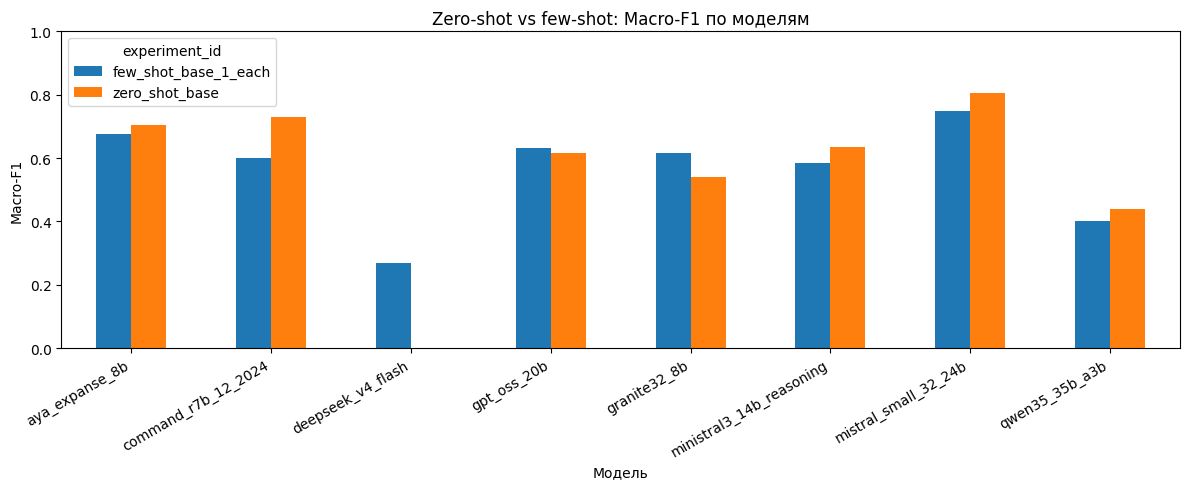

In [ ]:
plot_zero_vs_few_all_models(all_models_ablation_summary_df)

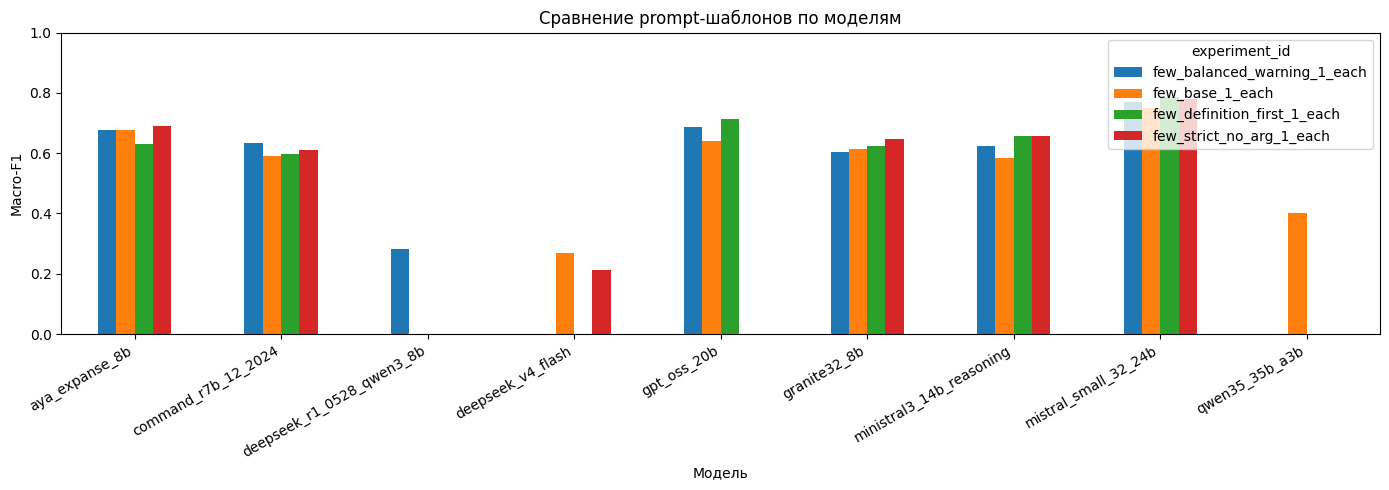

In [ ]:
plot_prompt_templates_all_models(all_models_ablation_summary_df)

experiment_id,few_1_1_1,few_1_3_1_noarg_boost,few_1_5_1_noarg_boost
model,,,
aya_expanse_8b,0.6102,0.5586,0.6496
command_r7b_12_2024,0.4848,0.4368,0.5111
deepseek_v4_flash,0.0000,0.0000,0.0000
gpt_oss_20b,0.5862,0.6087,0.6281
granite32_8b,0.6269,0.6016,0.5899
ministral3_14b_reasoning,0.5116,0.5376,0.5918
mistral_small_32_24b,0.7091,0.6286,0.7899


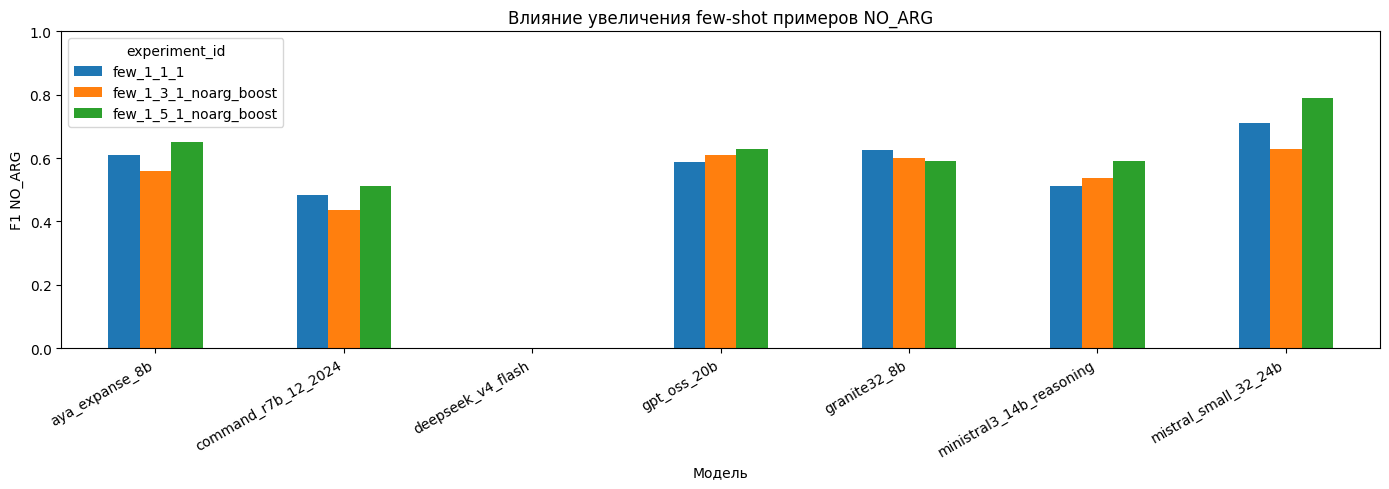

In [ ]:
plot_noarg_fewshot_all_models(all_models_ablation_summary_df)

,experiment_id,mean_macro_f1,mean_f1_NO_ARG,mean_f1_AGAINST,mean_f1_FOR,n_valid_models
2,few_1_5_1_noarg_boost,0.620957,0.537200,0.623229,0.714843,7
0,few_1_1_1,0.613771,0.504114,0.639643,0.716500,7
1,few_1_3_1_noarg_boost,0.601243,0.481700,0.630243,0.714743,7


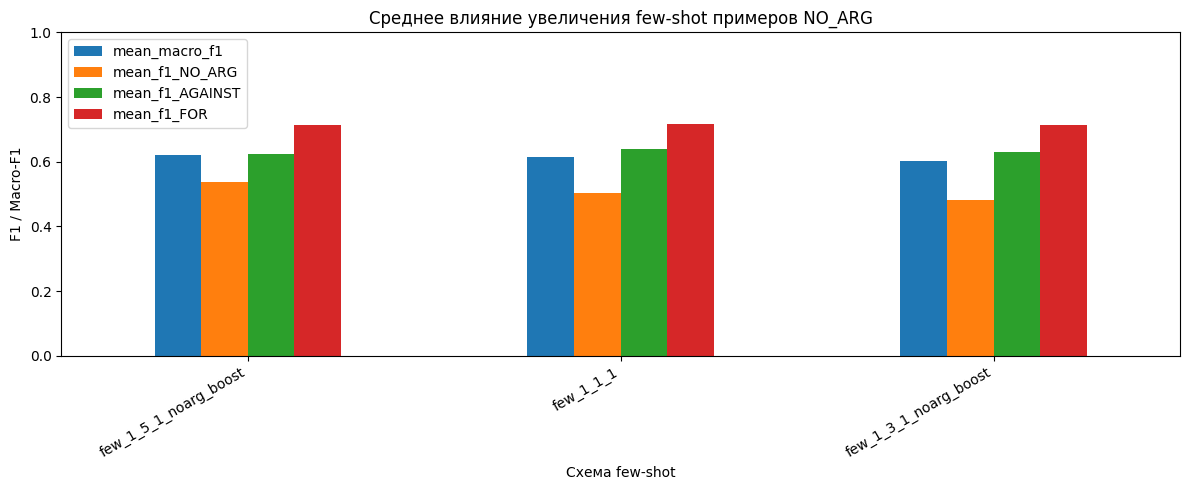

In [ ]:
plot_noarg_fewshot_average(all_models_ablation_summary_df)

# **Классификация**

**Первичная проверка поведения модели**

In [ ]:
def make_sanity_df(eval_df: pd.DataFrame) -> pd.DataFrame:
    return (
        eval_df
        .groupby(["topic", "label"], group_keys=False)
        .head(1)
        .reset_index(drop=True)
    )

In [ ]:
def run_sanity_check(model_alias: str, model_id: str) -> pd.DataFrame:
    sanity_df = make_sanity_df(eval_df)

    pred_df = evaluate_lmstudio_model(
        model_alias=f"{model_alias}_sanity",
        model_id=model_id,
        train_df=train_df,
        eval_df=sanity_df,
    )

    pred_df["gold_name"] = pred_df["gold"].map(LABEL_ID2NAME)
    pred_df["pred_name"] = pred_df["pred"].map(LABEL_ID2NAME)

    display(
        pred_df[
            [
                "topic",
                "text",
                "gold_name",
                "pred_name",
                "pred_raw",
                "model_id",
            ]
        ]
    )

    print("Диагностика:")
    print(json.dumps(prediction_diagnostics(pred_df), ensure_ascii=False, indent=2))

    return pred_df

In [ ]:
def clear_classification_files_for_alias(model_alias: str) -> None:
    safe_alias = safe_filename(model_alias)

    patterns = [
        f"cache_{safe_alias}*.json",
        f"predictions_{safe_alias}*.csv",
        f"metrics_{safe_alias}*.json",
    ]

    for pattern in patterns:
        for path in CLASSIFICATION_DIR.glob(pattern):
            print("Удаляю:", path)
            path.unlink()

In [ ]:
def run_classification_models(
    model_runs: list[dict[str, Any]],
    train_df: pd.DataFrame,
    eval_df: pd.DataFrame,
    run_sanity_first: bool = True,
    max_sanity_fallback: int = 2,
    max_full_fallback_for_valid: int = 30,
    clear_old_for_alias: bool = False,
    stop_on_error: bool = False,
) -> pd.DataFrame:
    run_statuses = []

    for cfg in model_runs:
        alias = cfg["alias"]
        model_id = cfg["model_id"]

        instance_id = None

        print("\n" + "=" * 100)
        print(f"Запуск модели: {alias}")
        print(f"Model id: {model_id}")

        try:
            if clear_old_for_alias:
                clear_classification_files_for_alias(alias)
                clear_classification_files_for_alias(f"{alias}_sanity")

            if USE_AUTO_LOAD_UNLOAD:
                instance_id = load_lmstudio_model(
                    model_id=model_id,
                    context_length=cfg.get("context_length", 4096),
                    flash_attention=cfg.get("flash_attention", True),
                    offload_kv_cache_to_gpu=cfg.get("offload_kv_cache_to_gpu", True),
                    eval_batch_size=cfg.get("eval_batch_size", 512),
                    num_experts=cfg.get("num_experts"),
                    unload_existing=True,
                )
            else:
                print("Автозагрузка отключена")

            sanity_fallback = None
            sanity_diag = None
            sanity_is_valid = True

            if run_sanity_first:
                print("\nSanity check...")
                sanity_pred = run_sanity_check(alias, model_id)
                sanity_diag = prediction_diagnostics(sanity_pred)
                sanity_fallback = sanity_diag["fallback_count"]

                sanity_is_valid = is_classification_run_valid(
                    sanity_diag,
                    max_fallback=max_sanity_fallback,
                    min_pred_classes=2,
                    max_class_share=0.90,
                )

                if not sanity_is_valid:
                    print(
                        f"Sanity check не пройден: "
                        f"fallback={sanity_diag['fallback_count']}, "
                        f"n_pred_classes={sanity_diag['n_pred_classes']}, "
                        f"max_class_share={sanity_diag['max_class_share']}. "
                        f"Полный прогон модели {alias} пропущен"
                    )

                    run_statuses.append(
                        {
                            "alias": alias,
                            "model_id": model_id,
                            "status": "skipped_after_sanity",
                            "macro_f1_over_topics": None,
                            "accuracy": None,
                            "sanity_fallback_count": sanity_fallback,
                            "fallback_count": None,
                            "repaired_count": None,
                            "direct_retry_count": None,
                            "n_pred_classes": sanity_diag["n_pred_classes"],
                            "max_class_share": sanity_diag["max_class_share"],
                            "pred_distribution": json.dumps(
                                sanity_diag["pred_distribution"],
                                ensure_ascii=False,
                            ),
                            "is_valid": False,
                            "error": None,
                        }
                    )

                    continue

            print("\nПолный прогон...")
            pred_df = evaluate_lmstudio_model(
                model_alias=alias,
                model_id=model_id,
                train_df=train_df,
                eval_df=eval_df,
            )

            metrics = calculate_metrics(pred_df)
            save_metrics(alias, metrics)

            diag = prediction_diagnostics(pred_df)

            is_valid = is_classification_run_valid(
                diag,
                max_fallback=max_full_fallback_for_valid,
                min_pred_classes=2,
                max_class_share=0.90,
            )

            run_statuses.append(
                {
                    "alias": alias,
                    "model_id": model_id,
                    "status": "ok",
                    "macro_f1_over_topics": metrics["macro_f1_over_topics"],
                    "accuracy": metrics["accuracy"],
                    "sanity_fallback_count": sanity_fallback,
                    "fallback_count": diag["fallback_count"],
                    "repaired_count": diag["repaired_count"],
                    "direct_retry_count": diag["direct_retry_count"],
                    "n_pred_classes": diag["n_pred_classes"],
                    "max_class_share": diag["max_class_share"],
                    "pred_distribution": json.dumps(
                        diag["pred_distribution"],
                        ensure_ascii=False,
                    ),
                    "is_valid": is_valid,
                    "error": None,
                }
            )

            print("Метрики:")
            print(json.dumps(metrics, ensure_ascii=False, indent=2))

            print("Диагностика:")
            print(json.dumps(diag, ensure_ascii=False, indent=2))

            if not is_valid:
                print(
                    f"Предупреждение: результат модели {alias} невалиден "
                    f"fallback={diag['fallback_count']}, "
                    f"n_pred_classes={diag['n_pred_classes']}, "
                    f"max_class_share={diag['max_class_share']}. "
                    f"!Результат не включать!"
                )

        except Exception as exc:
            print(f"Ошибка на модели {alias}: {exc}")

            run_statuses.append(
                {
                    "alias": alias,
                    "model_id": model_id,
                    "status": "error",
                    "macro_f1_over_topics": None,
                    "accuracy": None,
                    "sanity_fallback_count": None,
                    "fallback_count": None,
                    "repaired_count": None,
                    "direct_retry_count": None,
                    "n_pred_classes": None,
                    "max_class_share": None,
                    "pred_distribution": None,
                    "is_valid": False,
                    "error": str(exc),
                }
            )

            if stop_on_error:
                raise

        finally:
            if USE_AUTO_LOAD_UNLOAD:
                if instance_id is not None:
                    unload_lmstudio_model(instance_id, ignore_errors=True)

                unload_all_llms()
                time.sleep(5)

    status_df = pd.DataFrame(run_statuses)
    status_df.to_csv(
        CLASSIFICATION_DIR / "classification_run_status.csv",
        index=False,
        encoding="utf-8-sig",
    )

    return status_df

**Запуск классификации**

In [ ]:
classification_status_df = run_classification_models(
    model_runs=MODEL_RUNS,
    train_df=train_df,
    eval_df=eval_df,
    run_sanity_first=True,
    max_sanity_fallback=2,
    max_full_fallback_for_valid=30,
    clear_old_for_alias=False,
    stop_on_error=False,
)


Запуск модели: deepseek_v4_flash
Model id: qwen3.5-9b-deepseek-v4-flash
Загружаю модель: qwen3.5-9b-deepseek-v4-flash
Модель загружена.
instance_id: qwen3.5-9b-deepseek-v4-flash
load_time_seconds: 15.009
load_config: {'context_length': 4096, 'eval_batch_size': 512, 'parallel': 4, 'flash_attention': True, 'offload_kv_cache_to_gpu': True}

Sanity check...
Alias: deepseek_v4_flash_sanity
LM Studio model_id: qwen3.5-9b-deepseek-v4-flash


Evaluating deepseek_v4_flash_sanity:   0%|          | 0/9 [00:00<?, ?it/s]

,topic,text,gold_name,pred_name,pred_raw,model_id
0,vaccines,Вдобавок иммунитет в результате выздоровления ...,FOR,FOR,Thinking Process:\n\n1. **Analyze the Request...,qwen3.5-9b-deepseek-v4-flash
1,masks,"[USER], из-за того что много не выявленных бол...",FOR,FOR,The user wants me to classify a text relative ...,qwen3.5-9b-deepseek-v4-flash
2,masks,"[USER], Само название —-МЕДИЦИНСКАЯ МАСКА---го...",AGAINST,FOR,The user wants me to classify a given text rel...,qwen3.5-9b-deepseek-v4-flash
3,quarantine,"где народ митингует, там странным образом кара...",AGAINST,FOR,The user wants me to classify a text relative ...,qwen3.5-9b-deepseek-v4-flash
4,vaccines,"[USER], И Спида не существует, а прививки прид...",AGAINST,FOR,Thinking Process:\n\n1. **Analyze the Request...,qwen3.5-9b-deepseek-v4-flash
5,quarantine,А если ты привёз вирус домой и не прошёл каран...,FOR,FOR,The user wants me to classify a text relative ...,qwen3.5-9b-deepseek-v4-flash
6,masks,"Никому больше носить маску не нужно, и тому ес...",NO_ARG,FOR,The user wants me to classify a text relative ...,qwen3.5-9b-deepseek-v4-flash
7,quarantine,"Пенсионерам, которые сейчас сидят на карантине...",NO_ARG,FOR,Thinking Process:\n\n1. **Analyze the Request...,qwen3.5-9b-deepseek-v4-flash
8,vaccines,Лучше бы деньги на создание вакцины дали!,NO_ARG,FOR,Thinking Process:\n\n1. **Analyze the Request...,qwen3.5-9b-deepseek-v4-flash


Диагностика:
{
  "n": 9,
  "pred_distribution": {
    "FOR": 9
  },
  "n_pred_classes": 1,
  "max_class_share": 1.0,
  "fallback_count": 0,
  "repaired_count": 0,
  "direct_retry_count": 0
}
Sanity check не пройден: fallback=0, n_pred_classes=1, max_class_share=1.0. Полный прогон модели deepseek_v4_flash пропущен
Выгружена модель: qwen3.5-9b-deepseek-v4-flash

Запуск модели: ministral3_14b_reasoning
Model id: mistralai/ministral-3-14b-reasoning
Загружаю модель: mistralai/ministral-3-14b-reasoning
Модель загружена.
instance_id: mistralai/ministral-3-14b-reasoning
load_time_seconds: 29.757
load_config: {'context_length': 4096, 'eval_batch_size': 512, 'parallel': 4, 'flash_attention': True, 'offload_kv_cache_to_gpu': True}

Sanity check...
Alias: ministral3_14b_reasoning_sanity
LM Studio model_id: mistralai/ministral-3-14b-reasoning


Evaluating ministral3_14b_reasoning_sanity:   0%|          | 0/9 [00:00<?, ?it/s]

...

,topic,text,gold_name,pred_name,pred_raw,model_id
0,vaccines,Вдобавок иммунитет в результате выздоровления ...,FOR,NO_ARG,"Хорошо, давайте разберёмся с этой задачей. Мне...",deepseek/deepseek-r1-0528-qwen3-8b
1,masks,"[USER], из-за того что много не выявленных бол...",FOR,FOR,"Okay, let's tackle this classification task. T...",deepseek/deepseek-r1-0528-qwen3-8b
2,masks,"[USER], Само название —-МЕДИЦИНСКАЯ МАСКА---го...",AGAINST,NO_ARG,"Хорошо, давайте разберёмся с этой задачей. Мне...",deepseek/deepseek-r1-0528-qwen3-8b
3,quarantine,"где народ митингует, там странным образом кара...",AGAINST,NO_ARG,"Okay, let's tackle this classification task. T...",deepseek/deepseek-r1-0528-qwen3-8b
4,vaccines,"[USER], И Спида не существует, а прививки прид...",AGAINST,FOR,"Okay, let's tackle this classification task. T...",deepseek/deepseek-r1-0528-qwen3-8b
5,quarantine,А если ты привёз вирус домой и не прошёл каран...,FOR,NO_ARG,"Hmm, пользователь снова просит классифицироват...",deepseek/deepseek-r1-0528-qwen3-8b
6,masks,"Никому больше носить маску не нужно, и тому ес...",NO_ARG,NO_ARG,"Хорошо, давайте разберём этот запрос. Пользова...",deepseek/deepseek-r1-0528-qwen3-8b
7,quarantine,"Пенсионерам, которые сейчас сидят на карантине...",NO_ARG,FOR,"Okay, let's tackle this classification task. T...",deepseek/deepseek-r1-0528-qwen3-8b
8,vaccines,Лучше бы деньги на создание вакцины дали!,NO_ARG,FOR,"Okay, let's tackle this classification task. T...",deepseek/deepseek-r1-0528-qwen3-8b


Диагностика:
{
  "n": 9,
  "pred_distribution": {
    "NO_ARG": 5,
    "FOR": 4
  },
  "n_pred_classes": 2,
  "max_class_share": 0.5556,
  "fallback_count": 4,
  "repaired_count": 4,
  "direct_retry_count": 1
}
Sanity check не пройден: fallback=4, n_pred_classes=2, max_class_share=0.5556. Полный прогон модели deepseek_r1_0528_qwen3_8b пропущен
Выгружена модель: deepseek/deepseek-r1-0528-qwen3-8b

Запуск модели: qwen35_35b_a3b
Model id: qwen/qwen3.5-35b-a3b
Загружаю модель: qwen/qwen3.5-35b-a3b
Модель загружена.
instance_id: qwen/qwen3.5-35b-a3b
load_time_seconds: 77.657
load_config: {'context_length': 4096, 'eval_batch_size': 512, 'parallel': 4, 'flash_attention': True, 'num_experts': 8, 'offload_kv_cache_to_gpu': True}

Sanity check...
Alias: qwen35_35b_a3b_sanity
LM Studio model_id: qwen/qwen3.5-35b-a3b


Evaluating qwen35_35b_a3b_sanity:   0%|          | 0/9 [00:00<?, ?it/s]

,topic,text,gold_name,pred_name,pred_raw,model_id
0,vaccines,Вдобавок иммунитет в результате выздоровления ...,FOR,FOR,Thinking Process:\n\n1. **Analyze the Request...,qwen/qwen3.5-35b-a3b
1,masks,"[USER], из-за того что много не выявленных бол...",FOR,FOR,Thinking Process:\n\n1. **Analyze the Request...,qwen/qwen3.5-35b-a3b
2,masks,"[USER], Само название —-МЕДИЦИНСКАЯ МАСКА---го...",AGAINST,FOR,Thinking Process:\n\n1. **Analyze the Request...,qwen/qwen3.5-35b-a3b
3,quarantine,"где народ митингует, там странным образом кара...",AGAINST,FOR,Thinking Process:\n\n1. **Analyze the Request...,qwen/qwen3.5-35b-a3b
4,vaccines,"[USER], И Спида не существует, а прививки прид...",AGAINST,FOR,Thinking Process:\n\n1. **Analyze the Request...,qwen/qwen3.5-35b-a3b
5,quarantine,А если ты привёз вирус домой и не прошёл каран...,FOR,FOR,Thinking Process:\n\n1. **Analyze the Request...,qwen/qwen3.5-35b-a3b
6,masks,"Никому больше носить маску не нужно, и тому ес...",NO_ARG,FOR,Thinking Process:\n\n1. **Analyze the Request...,qwen/qwen3.5-35b-a3b
7,quarantine,"Пенсионерам, которые сейчас сидят на карантине...",NO_ARG,FOR,Thinking Process:\n\n1. **Analyze the Request...,qwen/qwen3.5-35b-a3b
8,vaccines,Лучше бы деньги на создание вакцины дали!,NO_ARG,FOR,Thinking Process:\n\n1. **Analyze the Request...,qwen/qwen3.5-35b-a3b


Диагностика:
{
  "n": 9,
  "pred_distribution": {
    "FOR": 9
  },
  "n_pred_classes": 1,
  "max_class_share": 1.0,
  "fallback_count": 0,
  "repaired_count": 0,
  "direct_retry_count": 0
}
Sanity check не пройден: fallback=0, n_pred_classes=1, max_class_share=1.0. Полный прогон модели qwen35_35b_a3b пропущен
Выгружена модель: qwen/qwen3.5-35b-a3b


**Ркзультаты эксперимента**

In [ ]:
display(classification_status_df)

,alias,model_id,status,macro_f1_over_topics,accuracy,sanity_fallback_count,fallback_count,repaired_count,direct_retry_count,n_pred_classes,max_class_share,pred_distribution,is_valid,error
0,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,skipped_after_sanity,NaN,NaN,0,NaN,NaN,NaN,1,1.0000,"{""FOR"": 9}",False,None
1,ministral3_14b_reasoning,mistralai/ministral-3-14b-reasoning,ok,0.5460,0.6044,0,0.0,0.0,0.0,3,0.6289,"{""AGAINST"": 283, ""FOR"": 138, ""NO_ARG"": 29}",True,None
2,granite32_8b,ibm/granite-3.2-8b,ok,0.6210,0.6356,0,0.0,0.0,0.0,3,0.4822,"{""AGAINST"": 217, ""FOR"": 126, ""NO_ARG"": 107}",True,None
3,command_r7b_12_2024,c4ai-command-r7b-12-2024,ok,0.5699,0.6089,0,0.0,0.0,0.0,3,0.4844,"{""FOR"": 218, ""AGAINST"": 154, ""NO_ARG"": 78}",True,None
4,phi4_mini_reasoning,microsoft/phi-4-mini-reasoning,skipped_after_sanity,NaN,NaN,5,NaN,NaN,NaN,3,0.5556,"{""NO_ARG"": 5, ""AGAINST"": 2, ""FOR"": 2}",False,None
5,aya_expanse_8b,aya-expanse-8b,ok,0.6467,0.6644,0,0.0,0.0,0.0,3,0.4578,"{""AGAINST"": 206, ""FOR"": 155, ""NO_ARG"": 89}",True,None
6,gpt_oss_20b,openai/gpt-oss-20b,ok,0.5988,0.6089,0,41.0,42.0,9.0,3,0.4756,"{""AGAINST"": 214, ""FOR"": 126, ""NO_ARG"": 110}",False,None
7,mistral_small_32_24b,mistral-small-3.2-24b-instruct-2506,ok,0.6954,0.7133,0,0.0,0.0,0.0,3,0.5067,"{""AGAINST"": 228, ""FOR"": 145, ""NO_ARG"": 77}",True,None
8,qwen35_9b,qwen/qwen3.5-9b,skipped_after_sanity,NaN,NaN,0,NaN,NaN,NaN,1,1.0000,"{""AGAINST"": 9}",False,None
9,deepseek_r1_0528_qwen3_8b,deepseek/deepseek-r1-0528-qwen3-8b,skipped_after_sanity,NaN,NaN,4,NaN,NaN,NaN,2,0.5556,"{""NO_ARG"": 5, ""FOR"": 4}",False,None


In [ ]:
all_metrics = load_all_metrics()
classification_summary_df = make_classification_summary_df(all_metrics)

In [ ]:
display(classification_summary_df)

,model,macro_f1_over_topics,accuracy,masks_f1,quarantine_f1,vaccines_f1,f1_AGAINST,f1_NO_ARG,f1_FOR
0,mistral_small_32_24b,0.6954,0.7133,0.7231,0.6937,0.6693,0.7566,0.5374,0.7932
1,aya_expanse_8b,0.6467,0.6644,0.7197,0.5960,0.6243,0.6798,0.5105,0.7672
2,granite32_8b,0.6210,0.6356,0.6733,0.5547,0.6350,0.6594,0.5447,0.6884
3,gpt_oss_20b,0.5988,0.6089,0.6636,0.5374,0.5954,0.6538,0.4692,0.6812
4,command_r7b_12_2024,0.5699,0.6089,0.6095,0.5280,0.5721,0.6118,0.4298,0.7174
5,ministral3_14b_reasoning,0.5460,0.6044,0.5658,0.5484,0.5239,0.6605,0.2570,0.7361


In [ ]:
classification_status_df = pd.read_csv(
    CLASSIFICATION_DIR / "classification_run_status.csv"
)

classification_summary_df = pd.read_csv(
    CLASSIFICATION_DIR / "classification_summary.csv"
)

valid_aliases = classification_status_df.loc[
    classification_status_df["is_valid"] == True,
    "alias"
].tolist()

valid_classification_summary_df = classification_summary_df[
    classification_summary_df["model"].isin(valid_aliases)
].copy()

display(valid_classification_summary_df)

valid_classification_summary_df.to_csv(
    CLASSIFICATION_DIR / "classification_summary_valid_only.csv",
    index=False,
    encoding="utf-8-sig",
)

,model,macro_f1_over_topics,accuracy,masks_f1,quarantine_f1,vaccines_f1,f1_AGAINST,f1_NO_ARG,f1_FOR
0,mistral_small_32_24b,0.6954,0.7133,0.7231,0.6937,0.6693,0.7566,0.5374,0.7932
1,aya_expanse_8b,0.6467,0.6644,0.7197,0.5960,0.6243,0.6798,0.5105,0.7672
2,granite32_8b,0.6210,0.6356,0.6733,0.5547,0.6350,0.6594,0.5447,0.6884
4,command_r7b_12_2024,0.5699,0.6089,0.6095,0.5280,0.5721,0.6118,0.4298,0.7174
5,ministral3_14b_reasoning,0.5460,0.6044,0.5658,0.5484,0.5239,0.6605,0.2570,0.7361


In [ ]:
def plot_classification_summary(summary_df: pd.DataFrame) -> None:
    if summary_df.empty:
        print("Нет данных для графика.")
        return

    plot_df = summary_df.set_index("model")[
        [
            "macro_f1_over_topics",
            "accuracy",
        ]
    ]

    plot_df.plot(kind="bar", figsize=(11, 5))

    plt.title("Сравнение моделей по качеству классификации аргументов")
    plt.xlabel("Модель")
    plt.ylabel("Значение метрики")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(
        CLASSIFICATION_DIR / "classification_summary.png",
        dpi=200,
    )

    plt.show()

In [ ]:
def plot_topic_f1(summary_df: pd.DataFrame) -> None:
    if summary_df.empty:
        print("Нет данных для графика.")
        return

    plot_df = summary_df.set_index("model")[
        [
            "masks_f1",
            "quarantine_f1",
            "vaccines_f1",
        ]
    ]

    plot_df.plot(kind="bar", figsize=(12, 5))

    plt.title("Macro-F1 моделей по темам")
    plt.xlabel("Модель")
    plt.ylabel("Macro-F1")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(
        CLASSIFICATION_DIR / "classification_topic_f1.png",
        dpi=200,
    )

    plt.show()

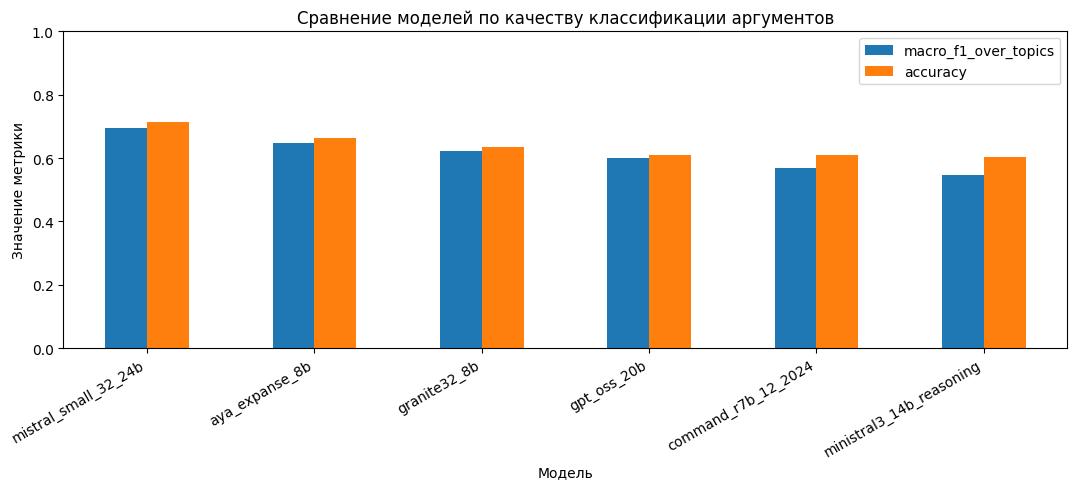

In [ ]:
plot_classification_summary(classification_summary_df)

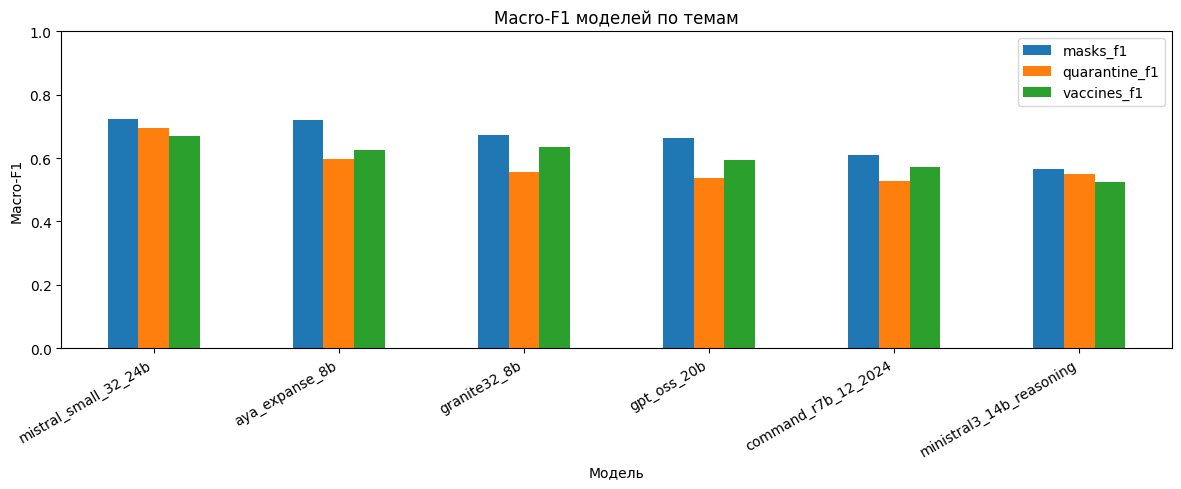

In [ ]:
plot_topic_f1(classification_summary_df)

In [ ]:
def load_predictions(model_alias: str) -> pd.DataFrame:
    path = predictions_path_for(model_alias)

    if not path.exists():
        raise FileNotFoundError(f"Не найден файл: {path}")

    return pd.read_csv(path)

In [ ]:
def analyze_best_classification_model(
    summary_df: pd.DataFrame,
    status_df: Optional[pd.DataFrame] = None,
) -> None:
    if summary_df.empty:
        print("Нет summary_df.")
        return

    candidate_df = summary_df.copy()

    if status_df is not None and not status_df.empty and "is_valid" in status_df.columns:
        valid_models = set(status_df.loc[status_df["is_valid"] == True, "alias"].tolist())
        candidate_df = candidate_df[candidate_df["model"].isin(valid_models)]

    if candidate_df.empty:
        print("Нет валидных моделей для анализа.")
        return

    best_model = candidate_df.iloc[0]["model"]
    print("Лучшая валидная модель:", best_model)

    pred_df = load_predictions(best_model)

    cm = confusion_matrix(
        pred_df["gold"],
        pred_df["pred"],
        labels=[0, 1, 2],
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[LABEL_ID2NAME[i] for i in [0, 1, 2]],
    )

    disp.plot(values_format="d")
    plt.title(f"Матрица ошибок: {best_model}")
    plt.tight_layout()

    plt.savefig(
        CLASSIFICATION_DIR / f"confusion_matrix_{safe_filename(best_model)}.png",
        dpi=200,
    )

    plt.show()

    pred_df["gold_name"] = pred_df["gold"].map(LABEL_ID2NAME)
    pred_df["pred_name"] = pred_df["pred"].map(LABEL_ID2NAME)

    errors_df = pred_df[pred_df["gold"] != pred_df["pred"]].copy()

    error_types = (
        errors_df
        .groupby(["topic", "gold_name", "pred_name"])
        .size()
        .reset_index(name="error_count")
        .sort_values("error_count", ascending=False)
    )

    print("Типы ошибок:")
    display(error_types)

    print("Примеры ошибок:")
    display(
        errors_df[
            [
                "topic",
                "thesis",
                "text",
                "gold_name",
                "pred_name",
                "pred_raw",
            ]
        ].head(20)
    )

Лучшая валидная модель: mistral_small_32_24b


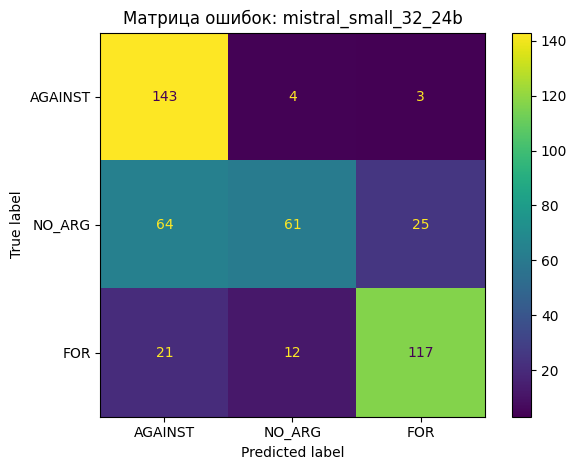

Типы ошибок:


,topic,gold_name,pred_name,error_count
13,vaccines,NO_ARG,AGAINST,25
8,quarantine,NO_ARG,AGAINST,22
4,masks,NO_ARG,AGAINST,17
7,quarantine,FOR,AGAINST,11
9,quarantine,NO_ARG,FOR,9
5,masks,NO_ARG,FOR,8
14,vaccines,NO_ARG,FOR,8
3,masks,FOR,NO_ARG,7
11,vaccines,FOR,AGAINST,6
12,vaccines,FOR,NO_ARG,5


Примеры ошибок:


,topic,thesis,text,gold_name,pred_name,pred_raw
4,vaccines,Вакцинация полезна для общества.,"Ну не читай, иди читай книжки) а губернатор св...",FOR,NO_ARG,LABEL_ID=1
11,vaccines,Вакцинация полезна для общества.,"Может вакцина и не скоро понадобиться, но все ...",FOR,NO_ARG,LABEL_ID=1
12,masks,Ношение масок полезно для общества.,"Никому больше носить маску не нужно, и тому ес...",NO_ARG,AGAINST,LABEL_ID=0
17,masks,Ношение масок полезно для общества.,"да маски платные, но есть еще места где их мож...",NO_ARG,FOR,LABEL_ID=2
20,masks,Ношение масок полезно для общества.,"перед тем, как одевать и снимать маску я руки ...",NO_ARG,FOR,LABEL_ID=2
24,masks,Ношение масок полезно для общества.,"[USER], я знаю лично многих людей, которые не ...",FOR,AGAINST,LABEL_ID=0
26,vaccines,Вакцинация полезна для общества.,Лучше бы деньги на создание вакцины дали!,NO_ARG,AGAINST,LABEL_ID=0
27,quarantine,Введение и соблюдение карантина полезно для об...,Нарушая санитарный карантин каждый становится ...,FOR,AGAINST,LABEL_ID=0
30,quarantine,Введение и соблюдение карантина полезно для об...,"Итак, вирус уже распространяется в РФ с геомет...",NO_ARG,AGAINST,LABEL_ID=0
35,vaccines,Вакцинация полезна для общества.,"[USER], если прививка будет как от гриппа, то ...",NO_ARG,AGAINST,LABEL_ID=0


In [ ]:
analyze_best_classification_model(classification_summary_df, classification_status_df)

# **Генерация аргументов**

**Задаём русские пояснения позиций для prompt'ов генерации**

In [ ]:
STANCE2RU = {
    "FOR": "в поддержку тезиса",
    "AGAINST": "против тезиса",
}

GENERATION_VARIANTS = [
    "Сделай акцент на причинно-следственной связи.",
    "Используй бытовой или общественный пример, но не выдумывай статистику.",
    "Сформулируй аргумент в нейтральном научно-популярном стиле.",
    "Сделай аргумент кратким и логически последовательным.",
    "Добавь объяснение, почему позиция может быть полезна или вредна для общества.",
]

**Набор заданий для генерации аргументов по темам и позициям**

In [ ]:
def make_generation_tasks(
    n_per_topic_stance: int = N_GENERATION_PER_TOPIC_STANCE,
    save_path: Path = GENERATION_DIR / "generation_tasks.csv",
) -> pd.DataFrame:
    rows = []

    for topic, thesis in TOPIC2THESIS.items():
        for stance in ["FOR", "AGAINST"]:
            for i in range(n_per_topic_stance):
                task_id = f"{topic}__{stance}__{i:03d}"
                variant = GENERATION_VARIANTS[i % len(GENERATION_VARIANTS)]

                rows.append(
                    {
                        "task_id": task_id,
                        "topic": topic,
                        "thesis": thesis,
                        "stance": stance,
                        "stance_ru": STANCE2RU[stance],
                        "variant_id": i % len(GENERATION_VARIANTS),
                        "generation_instruction": variant,
                    }
                )

    df = pd.DataFrame(rows)
    df.to_csv(save_path, index=False, encoding="utf-8-sig")
    return df

In [ ]:
generation_tasks_df = make_generation_tasks()

display(generation_tasks_df.head())

,task_id,topic,thesis,stance,stance_ru,variant_id,generation_instruction
0,masks__FOR__000,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,0,Сделай акцент на причинно-следственной связи.
1,masks__FOR__001,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,1,"Используй бытовой или общественный пример, но ..."
2,masks__FOR__002,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,2,Сформулируй аргумент в нейтральном научно-попу...
3,masks__FOR__003,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,3,Сделай аргумент кратким и логически последоват...
4,masks__FOR__004,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,4,"Добавь объяснение, почему позиция может быть п..."


In [ ]:
display(generation_tasks_df.tail())

,task_id,topic,thesis,stance,stance_ru,variant_id,generation_instruction
115,vaccines__AGAINST__015,vaccines,Вакцинация полезна для общества.,AGAINST,против тезиса,0,Сделай акцент на причинно-следственной связи.
116,vaccines__AGAINST__016,vaccines,Вакцинация полезна для общества.,AGAINST,против тезиса,1,"Используй бытовой или общественный пример, но ..."
117,vaccines__AGAINST__017,vaccines,Вакцинация полезна для общества.,AGAINST,против тезиса,2,Сформулируй аргумент в нейтральном научно-попу...
118,vaccines__AGAINST__018,vaccines,Вакцинация полезна для общества.,AGAINST,против тезиса,3,Сделай аргумент кратким и логически последоват...
119,vaccines__AGAINST__019,vaccines,Вакцинация полезна для общества.,AGAINST,против тезиса,4,"Добавь объяснение, почему позиция может быть п..."


In [ ]:
print("Всего заданий:", len(generation_tasks_df))

Всего заданий: 120


In [ ]:
def build_generation_messages(row: pd.Series) -> list[dict[str, str]]:
  system_prompt = (
      "/no_think\n"
      "Ты генерируешь аргументы на русском языке. "
      "Нужно создать один короткий аргумент по заданному тезису и позиции. "
      "Не используй reasoning-блоки, теги <think>, markdown, списки или пояснения. "
      "Не выдумывай конкретные статистические данные, названия исследований или ссылки. "
      "Отвечай только самим аргументом."
  )

  user_prompt = f"""
    Тезис: {row["thesis"]}
    Требуемая позиция: {row["stance"]} — {row["stance_ru"]}.

    Дополнительное требование: {row["generation_instruction"]}

    Сгенерируй один краткий аргумент, который:
    1) соответствует заданной позиции;
    2) содержит причину, следствие, пример или объяснение;
    3) не является простым эмоциональным мнением;
    4) состоит из 1–3 предложений.

    Не используй теги <think> или рассуждения.
    Верни только готовый аргумент.

    Аргумент:""".strip()

  return [{"role": "system", "content": system_prompt},
          {"role": "user", "content": user_prompt},]

In [ ]:
def clean_generated_argument(text: str) -> str:
    text = remove_thinking_blocks(text)
    text = str(text).strip()

    # Удаляем markdown code fences
    text = re.sub(r"^```[a-zA-Zа-яА-Я0-9_-]*", "", text).strip()
    text = re.sub(r"```$", "", text).strip()

    # Удаляем типичные заголовки
    text = re.sub(
        r"^(Ответ|Аргумент|Сгенерированный аргумент)\s*:\s*",
        "",
        text,
        flags=re.I,
    ).strip()

    # Если модель вывела Thinking Process, пытаемся оставить только финальную часть
    patterns = [
        r"(?i)final answer\s*:\s*(.*)",
        r"(?i)final argument\s*:\s*(.*)",
        r"(?i)argument\s*:\s*(.*)",
        r"(?i)итоговый аргумент\s*:\s*(.*)",
        r"(?i)аргумент\s*:\s*(.*)",
    ]

    for pattern in patterns:
        match = re.search(pattern, text, flags=re.S)
        if match:
            text = match.group(1).strip()
            break

    # Если в конце идет англоязычная инструкция типа Need a short argument..., отрезаем ее
    text = re.split(
        r"(?i)\bNeed a short argument\b|\bWe need\b|\bThe user asks\b|\bNow craft\b",
        text,
        maxsplit=1,
    )[0].strip()

    # Убираем строки-списки
    lines = [line.strip(" -•\t") for line in text.splitlines() if line.strip()]
    text = " ".join(lines)

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
def read_csv_if_exists(path: Path) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()

In [ ]:
def save_df(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, encoding="utf-8-sig")

In [ ]:
def run_generation_for_model(
    model_alias: str,
    model_id: str,
    tasks_df: pd.DataFrame,
    output_path: Path = GENERATION_DIR / "generated_arguments.csv",
    temperature: float = 0.7,
    top_p: float = 0.9,
    max_tokens: int = 180,
    request_pause: float = 0.2,
) -> pd.DataFrame:
    actual_model_id = resolve_model_id(model_id)

    print("Generation alias:", model_alias)
    print("LM Studio model_id:", actual_model_id)

    generated_df = read_csv_if_exists(output_path)

    done_ids = set()
    if not generated_df.empty:
        done_ids = set(generated_df["argument_id"].astype(str).tolist())

    records = []

    for _, row in tqdm(tasks_df.iterrows(), total=len(tasks_df), desc=f"Generation: {model_alias}"):
        argument_id = f"{model_alias}__{row['task_id']}"

        if argument_id in done_ids:
            continue

        messages = build_generation_messages(row)

        raw = chat_complete_lmstudio(
            messages=messages,
            model_id=actual_model_id,
            temperature=temperature,
            top_p=top_p,
            max_tokens=max_tokens,
        )

        argument = clean_generated_argument(raw)

        records.append(
            {
                "argument_id": argument_id,
                "model_alias": model_alias,
                "model_id": actual_model_id,
                "task_id": row["task_id"],
                "topic": row["topic"],
                "thesis": row["thesis"],
                "stance": row["stance"],
                "stance_ru": row["stance_ru"],
                "generation_instruction": row["generation_instruction"],
                "generated_argument": argument,
                "raw_generation": raw,
            }
        )

        if len(records) % 5 == 0:
            new_df = pd.DataFrame(records)
            generated_df = pd.concat([generated_df, new_df], ignore_index=True)
            generated_df = generated_df.drop_duplicates(subset=["argument_id"], keep="last")
            save_df(generated_df, output_path)
            records = []

        time.sleep(request_pause)

    if records:
        new_df = pd.DataFrame(records)
        generated_df = pd.concat([generated_df, new_df], ignore_index=True)
        generated_df = generated_df.drop_duplicates(subset=["argument_id"], keep="last")
        save_df(generated_df, output_path)

    return generated_df

In [ ]:
GENERATION_MODEL_RUNS = MODEL_RUNS.copy()

In [ ]:
def run_generation_models(
    model_runs: list[dict[str, Any]],
    tasks_df: pd.DataFrame,
    stop_on_error: bool = False,
) -> pd.DataFrame:
    statuses = []

    for cfg in model_runs:
        alias = cfg["alias"]
        model_id = cfg["model_id"]
        instance_id = None

        print("\n" + "=" * 100)
        print("Генерация:", alias)

        try:
            if USE_AUTO_LOAD_UNLOAD:
                instance_id = load_lmstudio_model(
                    model_id=model_id,
                    context_length=cfg.get("context_length", 4096),
                    flash_attention=cfg.get("flash_attention", True),
                    offload_kv_cache_to_gpu=cfg.get("offload_kv_cache_to_gpu", True),
                    eval_batch_size=cfg.get("eval_batch_size", 512),
                    num_experts=cfg.get("num_experts"),
                    unload_existing=True,
                )
            else:
                print("Автозагрузка отключена. Загрузи модель вручную.")

            before_df = read_csv_if_exists(GENERATION_DIR / "generated_arguments.csv")
            before_n = len(before_df)

            generated_df = run_generation_for_model(
                model_alias=alias,
                model_id=model_id,
                tasks_df=tasks_df,
                temperature=0.7,
                top_p=0.9,
                max_tokens=180,
            )

            after_n = len(generated_df)

            statuses.append(
                {
                    "alias": alias,
                    "model_id": model_id,
                    "status": "ok",
                    "generated_new": int(after_n - before_n),
                    "total_generated": int(after_n),
                    "error": None,
                }
            )

        except Exception as exc:
            print("Ошибка генерации:", exc)

            statuses.append(
                {
                    "alias": alias,
                    "model_id": model_id,
                    "status": "error",
                    "generated_new": None,
                    "total_generated": None,
                    "error": str(exc),
                }
            )

            if stop_on_error:
                raise

        finally:
            if USE_AUTO_LOAD_UNLOAD:
                if instance_id is not None:
                    unload_lmstudio_model(instance_id, ignore_errors=True)
                unload_all_llms()
                time.sleep(5)

    status_df = pd.DataFrame(statuses)
    status_df.to_csv(
        GENERATION_DIR / "generation_run_status.csv",
        index=False,
        encoding="utf-8-sig",
    )

    return status_df

**Запуск генерации**

In [ ]:
generation_status_df = run_generation_models(
    model_runs=GENERATION_MODEL_RUNS,
    tasks_df=generation_tasks_df,
    stop_on_error=False,
)


Генерация: deepseek_v4_flash
Загружаю модель: qwen3.5-9b-deepseek-v4-flash
Модель загружена.
instance_id: qwen3.5-9b-deepseek-v4-flash
load_time_seconds: 14.709
load_config: {'context_length': 4096, 'eval_batch_size': 512, 'parallel': 4, 'flash_attention': True, 'offload_kv_cache_to_gpu': True}
Generation alias: deepseek_v4_flash
LM Studio model_id: qwen3.5-9b-deepseek-v4-flash


Generation: deepseek_v4_flash:   0%|          | 0/120 [00:00<?, ?it/s]

Выгружена модель: qwen3.5-9b-deepseek-v4-flash

Генерация: ministral3_14b_reasoning
Загружаю модель: mistralai/ministral-3-14b-reasoning
Модель загружена.
instance_id: mistralai/ministral-3-14b-reasoning
load_time_seconds: 30.27
load_config: {'context_length': 4096, 'eval_batch_size': 512, 'parallel': 4, 'flash_attention': True, 'offload_kv_cache_to_gpu': True}
Generation alias: ministral3_14b_reasoning
LM Studio model_id: mistralai/ministral-3-14b-reasoning


Generation: ministral3_14b_reasoning:   0%|          | 0/120 [00:00<?, ?it/s]

Выгружена модель: mistralai/ministral-3-14b-reasoning

Генерация: granite32_8b
Загружаю модель: ibm/granite-3.2-8b
Модель загружена.
instance_id: ibm/granite-3.2-8b
load_time_seconds: 16.896
load_config: {'context_length': 4096, 'eval_batch_size': 512, 'parallel': 4, 'flash_attention': True, 'offload_kv_cache_to_gpu': True}
Generation alias: granite32_8b
LM Studio model_id: ibm/granite-3.2-8b


...

Выгружена модель: qwen/qwen3.5-9b

Генерация: deepseek_r1_0528_qwen3_8b
Загружаю модель: deepseek/deepseek-r1-0528-qwen3-8b
Модель загружена.
instance_id: deepseek/deepseek-r1-0528-qwen3-8b
load_time_seconds: 16.979
load_config: {'context_length': 4096, 'eval_batch_size': 512, 'parallel': 4, 'flash_attention': True, 'offload_kv_cache_to_gpu': True}
Generation alias: deepseek_r1_0528_qwen3_8b
LM Studio model_id: deepseek/deepseek-r1-0528-qwen3-8b


Generation: deepseek_r1_0528_qwen3_8b:   0%|          | 0/120 [00:00<?, ?it/s]

Выгружена модель: deepseek/deepseek-r1-0528-qwen3-8b

Генерация: qwen35_35b_a3b
Загружаю модель: qwen/qwen3.5-35b-a3b
Модель загружена.
instance_id: qwen/qwen3.5-35b-a3b
load_time_seconds: 77.831
load_config: {'context_length': 4096, 'eval_batch_size': 512, 'parallel': 4, 'flash_attention': True, 'num_experts': 8, 'offload_kv_cache_to_gpu': True}
Generation alias: qwen35_35b_a3b
LM Studio model_id: qwen/qwen3.5-35b-a3b


Generation: qwen35_35b_a3b:   0%|          | 0/120 [00:00<?, ?it/s]

Выгружена модель: qwen/qwen3.5-35b-a3b


**Результаты генерации**

In [ ]:
display(generation_status_df)

,alias,model_id,status,generated_new,total_generated,error
0,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,ok,120,120,None
1,ministral3_14b_reasoning,mistralai/ministral-3-14b-reasoning,ok,120,240,None
2,granite32_8b,ibm/granite-3.2-8b,ok,120,360,None
3,command_r7b_12_2024,c4ai-command-r7b-12-2024,ok,120,480,None
4,phi4_mini_reasoning,microsoft/phi-4-mini-reasoning,ok,120,600,None
5,aya_expanse_8b,aya-expanse-8b,ok,120,720,None
6,gpt_oss_20b,openai/gpt-oss-20b,ok,120,840,None
7,mistral_small_32_24b,mistral-small-3.2-24b-instruct-2506,ok,120,960,None
8,qwen35_9b,qwen/qwen3.5-9b,ok,120,1080,None
9,deepseek_r1_0528_qwen3_8b,deepseek/deepseek-r1-0528-qwen3-8b,ok,120,1200,None


In [ ]:
generated_df = pd.read_csv(GENERATION_DIR / "generated_arguments.csv")
display(generated_df.head())

,argument_id,model_alias,model_id,task_id,topic,thesis,stance,stance_ru,generation_instruction,generated_argument,raw_generation
0,deepseek_v4_flash__masks__FOR__000,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,masks__FOR__000,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,Сделай акцент на причинно-следственной связи.,嗯，用户要求我生成一个支持“佩戴口罩对社会有益”这个论点的简短论证。需要满足几个条件：用俄语...,嗯，用户要求我生成一个支持“佩戴口罩对社会有益”这个论点的简短论证。需要满足几个条件：用俄语...
1,deepseek_v4_flash__masks__FOR__001,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,masks__FOR__001,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,"Используй бытовой или общественный пример, но ...",Thinking Process: 1. **Analyze the Request:** ...,Thinking Process:\n\n1. **Analyze the Request...
2,deepseek_v4_flash__masks__FOR__002,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,masks__FOR__002,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,Сформулируй аргумент в нейтральном научно-попу...,The user wants me to generate a short argument...,The user wants me to generate a short argument...
3,deepseek_v4_flash__masks__FOR__003,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,masks__FOR__003,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,Сделай аргумент кратким и логически последоват...,NaN,We need to generate one short argument support...
4,deepseek_v4_flash__masks__FOR__004,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,masks__FOR__004,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,"Добавь объяснение, почему позиция может быть п...",Понял задачу. Нужно сгенерировать один коротки...,Понял задачу. Нужно сгенерировать один коротки...


In [ ]:
display(generated_df.tail())

,argument_id,model_alias,model_id,task_id,topic,thesis,stance,stance_ru,generation_instruction,generated_argument,raw_generation
1315,qwen35_35b_a3b__vaccines__AGAINST__015,qwen35_35b_a3b,qwen/qwen3.5-35b-a3b,vaccines__AGAINST__015,vaccines,Вакцинация полезна для общества.,AGAINST,против тезиса,Сделай акцент на причинно-следственной связи.,Thinking Process: 1. **Analyze the Request:** ...,Thinking Process:\n\n1. **Analyze the Request...
1316,qwen35_35b_a3b__vaccines__AGAINST__016,qwen35_35b_a3b,qwen/qwen3.5-35b-a3b,vaccines__AGAINST__016,vaccines,Вакцинация полезна для общества.,AGAINST,против тезиса,"Используй бытовой или общественный пример, но ...","`). * No markdown, lists, or explanations in t...","`).\n * No markdown, lists, or explan..."
1317,qwen35_35b_a3b__vaccines__AGAINST__017,qwen35_35b_a3b,qwen/qwen3.5-35b-a3b,vaccines__AGAINST__017,vaccines,Вакцинация полезна для общества.,AGAINST,против тезиса,Сформулируй аргумент в нейтральном научно-попу...,Thinking Process: 1. **Analyze the Request:** ...,Thinking Process:\n\n1. **Analyze the Request...
1318,qwen35_35b_a3b__vaccines__AGAINST__018,qwen35_35b_a3b,qwen/qwen3.5-35b-a3b,vaccines__AGAINST__018,vaccines,Вакцинация полезна для общества.,AGAINST,против тезиса,Сделай аргумент кратким и логически последоват...,"`), markdown, lists, or explanations. * No inv...","`), markdown, lists, or explanations.\n ..."
1319,qwen35_35b_a3b__vaccines__AGAINST__019,qwen35_35b_a3b,qwen/qwen3.5-35b-a3b,vaccines__AGAINST__019,vaccines,Вакцинация полезна для общества.,AGAINST,против тезиса,"Добавь объяснение, почему позиция может быть п...",Thinking Process: 1. **Analyze the Request:** ...,Thinking Process:\n\n1. **Analyze the Request...


In [ ]:
print("Всего сгенерировано:", len(generated_df))

Всего сгенерировано: 1320


**Доля технических артефактов в сгенерированных аргументах**

In [ ]:
def generation_artifact_diagnostics(generated_df: pd.DataFrame) -> pd.DataFrame:
    df = generated_df.copy()

    text = df["generated_argument"].astype(str)

    df["empty"] = text.str.strip().eq("")
    df["too_short"] = text.str.len() < 30

    df["has_english_markers"] = text.str.contains(
        r"\bThesis\b|\bArgument\b|\bClaim\b|\bStance\b|\bFOR\b|\bAGAINST\b|"
        r"\bThinking Process\b|\bNeed a short argument\b|\bWe need\b|\bThe user asks\b",
        regex=True,
        case=False,
    )

    df["has_markdown_bullets"] = text.str.contains(
        r"^\s*[\*\-\•]",
        regex=True,
    )

    df["has_prompt_echo"] = text.str.contains(
        r"Тезис:|Требуемая позиция:|Аргумент:",
        regex=True,
        case=False,
    )

    df["has_reasoning_text"] = text.str.contains(
        r"Хм, пользователь|Давай подумаем|пользователь просит|"
        r"Thinking Process|Analyze the Request|Let's craft|Need a short argument",
        regex=True,
        case=False,
    )

    artifact_cols = [
        "empty",
        "too_short",
        "has_english_markers",
        "has_markdown_bullets",
        "has_prompt_echo",
        "has_reasoning_text",
    ]

    df["has_any_artifact"] = df[artifact_cols].any(axis=1)

    summary = (
        df
        .groupby("model_alias")
        .agg(
            n=("argument_id", "count"),
            empty=("empty", "sum"),
            too_short=("too_short", "sum"),
            english_markers=("has_english_markers", "sum"),
            markdown_bullets=("has_markdown_bullets", "sum"),
            prompt_echo=("has_prompt_echo", "sum"),
            reasoning_text=("has_reasoning_text", "sum"),
            artifact_examples=("has_any_artifact", "sum"),
        )
        .reset_index()
    )

    summary["artifact_share"] = (
        summary["artifact_examples"] / summary["n"]
    ).round(3)

    return summary

In [ ]:
generated_df = pd.read_csv(GENERATION_DIR / "generated_arguments.csv")

artifact_summary = generation_artifact_diagnostics(generated_df)

display(artifact_summary)

artifact_summary.to_csv(
    GENERATION_DIR / "generation_artifact_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

,model_alias,n,empty,too_short,english_markers,markdown_bullets,prompt_echo,reasoning_text,artifact_examples,artifact_share
0,aya_expanse_8b,120,0,0,0,0,0,0,0,0.000
1,command_r7b_12_2024,120,0,0,4,0,0,0,4,0.033
2,deepseek_r1_0528_qwen3_8b,120,0,0,12,0,0,90,95,0.792
3,deepseek_v4_flash,120,0,4,111,10,10,58,116,0.967
4,gpt_oss_20b,120,0,1,103,0,0,31,104,0.867
5,granite32_8b,120,0,0,0,0,0,0,0,0.000
6,ministral3_14b_reasoning,120,0,0,2,0,0,0,2,0.017
7,mistral_small_32_24b,120,0,0,0,0,0,0,0,0.000
8,phi4_mini_reasoning,120,0,1,20,1,7,0,26,0.217
9,qwen35_35b_a3b,120,0,0,120,15,4,120,120,1.000


# **Оценка качества генерации: LLM-as-a-Judge**

**Критерии оценки**

In [ ]:
CRITERIA = [
    "relevance",
    "stance_consistency",
    "argumentativeness",
    "coherence",
    "factual_caution",
    "format_cleanliness",
]

In [ ]:
# самая стабильная сильная модель
JUDGE_MODEL_ALIAS = "mistral_small_32_24b_judge"
JUDGE_MODEL_ID = "mistral-small-3.2-24b-instruct-2506"

**prompt для модели-судьи**

In [ ]:
def build_judge_messages(row: pd.Series) -> list[dict[str, str]]:
    system_prompt = (
        "/no_think\n"
        "Ты эксперт по анализу аргументации. "
        "Твоя задача — оценить качество сгенерированного аргумента. "
        "Оценивай строго по заданным критериям. "
        "Не используй reasoning-блоки, теги <think>, markdown или пояснения вне JSON. "
        "Верни только JSON без markdown-разметки."
    )

    user_prompt = f"""
    Оцени сгенерированный аргумент.

    Тезис: {row["thesis"]}
    Требуемая позиция: {row["stance"]} — {row["stance_ru"]}

    Аргумент:
    {row["generated_argument"]}

    Критерии оценки от 1 до 5:
    1 — очень плохо, 5 — отлично.

    Критерии:
    - relevance: аргумент относится к заданному тезису;
    - stance_consistency: аргумент соответствует требуемой позиции FOR или AGAINST;
    - argumentativeness: аргумент содержит обоснование, причину, следствие, пример или объяснение;
    - coherence: аргумент логически связный и грамматически корректный;
    - factual_caution: аргумент не содержит сомнительных конкретных фактов, выдуманной статистики или неподтвержденных ссылок;
    - format_cleanliness: ответ является только готовым аргументом, без reasoning-блоков, английских служебных фраз, markdown, повторов prompt или технических пояснений.

    Не используй теги <think>. Не добавляй рассуждения вне JSON.

    Верни строго JSON такого вида:
    {{
      "relevance": 1,
      "stance_consistency": 1,
      "argumentativeness": 1,
      "coherence": 1,
      "factual_caution": 1,
      "format_cleanliness": 1,
      "comment": "краткий комментарий"
    }}
    """.strip()

    return [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

In [ ]:
def extract_json_object(text: str) -> Optional[dict[str, Any]]:
    text = str(text).strip()

    text = re.sub(r"^```json", "", text, flags=re.I).strip()
    text = re.sub(r"^```", "", text).strip()
    text = re.sub(r"```$", "", text).strip()

    match = re.search(r"\{.*\}", text, flags=re.S)
    if not match:
        return None

    candidate = match.group(0)

    try:
        return json.loads(candidate)
    except json.JSONDecodeError:
        pass

    candidate_fixed = candidate.replace("'", '"')

    try:
        return json.loads(candidate_fixed)
    except json.JSONDecodeError:
        return None

**Оценку judge-модели к целому числу от 1 до 5**

In [ ]:
def normalize_score_or_none(value: Any) -> Optional[int]:
    try:
        value = float(value)
    except Exception:
        return None

    value = int(round(value))
    value = max(1, min(5, value))
    return value

**Проверка наличия всех критериев**

In [ ]:
def parse_judge_response(raw: str) -> dict[str, Any]:
    data = extract_json_object(raw)

    parsed = {}

    if data is None:
        for criterion in CRITERIA:
            parsed[criterion] = None

        parsed["comment"] = ""
        parsed["judge_parse_ok"] = False
        parsed["raw_judge_response"] = raw
        return parsed

    parse_ok = True

    for criterion in CRITERIA:
        score = normalize_score_or_none(data.get(criterion))
        parsed[criterion] = score

        if score is None:
            parse_ok = False

    parsed["comment"] = str(data.get("comment", "")).strip()
    parsed["judge_parse_ok"] = parse_ok
    parsed["raw_judge_response"] = raw

    return parsed

**Оценка всех сгенерированных аргументов моделью-судьёй**

In [ ]:
def run_judge_for_generated_arguments(
    judge_alias: str,
    judge_model_id: str,
    generated_path: Path = GENERATION_DIR / "generated_arguments.csv",
    output_path: Path = JUDGE_DIR / "judged_arguments.csv",
    temperature: float = 0.0,
    max_tokens: int = 350,
    request_pause: float = 0.2,
) -> pd.DataFrame:
    actual_judge_model_id = resolve_model_id(judge_model_id)

    generated_df = pd.read_csv(generated_path)

    if generated_df.empty:
        raise ValueError("Файл generated_arguments.csv пустой. Сначала запусти генерацию.")

    judged_df = read_csv_if_exists(output_path)

    done_keys = set()
    if not judged_df.empty:
        done_keys = set(judged_df["judge_key"].astype(str).tolist())

    records = []

    for _, row in tqdm(generated_df.iterrows(), total=len(generated_df), desc=f"Judge: {judge_alias}"):
        judge_key = f"{judge_alias}__{row['argument_id']}"

        if judge_key in done_keys:
            continue

        messages = build_judge_messages(row)

        raw = chat_complete_lmstudio(
            messages=messages,
            model_id=actual_judge_model_id,
            temperature=temperature,
            top_p=1.0,
            max_tokens=max_tokens,
        )

        parsed = parse_judge_response(raw)

        # Одна повторная попытка, если JSON не распарсился.
        if not parsed["judge_parse_ok"]:
            raw_retry = chat_complete_lmstudio(
                messages=[
                    {
                        "role": "system",
                        "content": "Верни только валидный JSON с числовыми оценками 1-5. Без markdown.",
                    },
                    {
                        "role": "user",
                        "content": (
                            "Исправь ответ так, чтобы это был валидный JSON указанного вида.\n\n"
                            f"Исходный ответ:\n{raw}"
                        ),
                    },
                ],
                model_id=actual_judge_model_id,
                temperature=0.0,
                top_p=1.0,
                max_tokens=max_tokens,
            )

            parsed_retry = parse_judge_response(raw_retry)

            if parsed_retry["judge_parse_ok"]:
                parsed = parsed_retry
                parsed["raw_judge_response"] = raw + " || JSON_RETRY_WITH: " + raw_retry
            else:
                parsed["raw_judge_response"] = raw + " || JSON_RETRY_WITH: " + raw_retry

        record = {
            "judge_key": judge_key,
            "judge_model_alias": judge_alias,
            "judge_model_id": actual_judge_model_id,
            "argument_id": row["argument_id"],
            "generated_by_model": row["model_alias"],
            "generator_model_id": row["model_id"],
            "topic": row["topic"],
            "thesis": row["thesis"],
            "stance": row["stance"],
            "stance_ru": row["stance_ru"],
            "generated_argument": row["generated_argument"],
            **parsed,
        }

        scores = [record[c] for c in CRITERIA if record[c] is not None]

        if len(scores) == len(CRITERIA):
            record["mean_score"] = sum(scores) / len(scores)
        else:
            record["mean_score"] = None

        records.append(record)

        if len(records) % 5 == 0:
            new_df = pd.DataFrame(records)
            judged_df = pd.concat([judged_df, new_df], ignore_index=True)
            judged_df = judged_df.drop_duplicates(subset=["judge_key"], keep="last")
            save_df(judged_df, output_path)
            records = []

        time.sleep(request_pause)

    if records:
        new_df = pd.DataFrame(records)
        judged_df = pd.concat([judged_df, new_df], ignore_index=True)
        judged_df = judged_df.drop_duplicates(subset=["judge_key"], keep="last")
        save_df(judged_df, output_path)

    return judged_df

**Загрузка judge-модели и запуск автоматической оценки**

In [ ]:
judge_instance_id = None

try:
    if USE_AUTO_LOAD_UNLOAD:
        judge_instance_id = load_lmstudio_model(
            model_id=JUDGE_MODEL_ID,
            context_length=4096,
            unload_existing=True,
        )
    else:
        print("Автозагрузка отключена")

    judged_df = run_judge_for_generated_arguments(
        judge_alias=JUDGE_MODEL_ALIAS,
        judge_model_id=JUDGE_MODEL_ID,
        temperature=0.0,
        max_tokens=350,
    )

finally:
    if USE_AUTO_LOAD_UNLOAD:
        if judge_instance_id is not None:
            unload_lmstudio_model(judge_instance_id, ignore_errors=True)
        unload_all_llms()

display(judged_df.head())

Загружаю модель: mistral-small-3.2-24b-instruct-2506
Модель загружена.
instance_id: mistral-small-3.2-24b-instruct-2506
load_time_seconds: 48.276
load_config: {'context_length': 4096, 'eval_batch_size': 512, 'parallel': 4, 'flash_attention': True, 'offload_kv_cache_to_gpu': True}


Judge: mistral_small_32_24b_judge:   0%|          | 0/1320 [00:00<?, ?it/s]

Выгружена модель: mistral-small-3.2-24b-instruct-2506


,judge_key,judge_model_alias,judge_model_id,argument_id,generated_by_model,generator_model_id,topic,thesis,stance,stance_ru,...,relevance,stance_consistency,argumentativeness,coherence,factual_caution,format_cleanliness,comment,judge_parse_ok,raw_judge_response,mean_score
0,mistral_small_32_24b_judge__deepseek_v4_flash_...,mistral_small_32_24b_judge,mistral-small-3.2-24b-instruct-2506,deepseek_v4_flash__masks__FOR__000,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,...,5,5,4,3,5,1,"Аргумент соответствует тезису и позиции FOR, с...",True,"```json\n{\n ""relevance"": 5,\n ""stance_consi...",3.833333
1,mistral_small_32_24b_judge__deepseek_v4_flash_...,mistral_small_32_24b_judge,mistral-small-3.2-24b-instruct-2506,deepseek_v4_flash__masks__FOR__001,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,...,1,1,1,1,5,1,"аргумент отсутствует, только технические поясн...",True,"```json\n{\n ""relevance"": 1,\n ""stance_consi...",1.666667
2,mistral_small_32_24b_judge__deepseek_v4_flash_...,mistral_small_32_24b_judge,mistral-small-3.2-24b-instruct-2506,deepseek_v4_flash__masks__FOR__002,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,...,5,5,4,5,5,3,"Аргумент релевантен, соответствует позиции FOR...",True,"```json\n{\n ""relevance"": 5,\n ""stance_consi...",4.500000
3,mistral_small_32_24b_judge__deepseek_v4_flash_...,mistral_small_32_24b_judge,mistral-small-3.2-24b-instruct-2506,deepseek_v4_flash__masks__FOR__003,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,...,1,1,1,1,5,3,аргумент отсутствует,True,"```json\n{\n ""relevance"": 1,\n ""stance_consi...",2.000000
4,mistral_small_32_24b_judge__deepseek_v4_flash_...,mistral_small_32_24b_judge,mistral-small-3.2-24b-instruct-2506,deepseek_v4_flash__masks__FOR__004,deepseek_v4_flash,qwen3.5-9b-deepseek-v4-flash,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,...,5,5,4,3,5,2,"Аргумент релевантен, поддерживает позицию FOR ...",True,"```json\n{\n ""relevance"": 5,\n ""stance_consi...",4.000000


In [ ]:
display(judged_df.tail())

,judge_key,judge_model_alias,judge_model_id,argument_id,generated_by_model,generator_model_id,topic,thesis,stance,stance_ru,...,relevance,stance_consistency,argumentativeness,coherence,factual_caution,format_cleanliness,comment,judge_parse_ok,raw_judge_response,mean_score
1315,mistral_small_32_24b_judge__qwen35_35b_a3b__va...,mistral_small_32_24b_judge,mistral-small-3.2-24b-instruct-2506,qwen35_35b_a3b__vaccines__AGAINST__015,qwen35_35b_a3b,qwen/qwen3.5-35b-a3b,vaccines,Вакцинация полезна для общества.,AGAINST,против тезиса,...,3,2,1,1,5,1,аргумент не соответствует требуемой позиции и ...,True,"```json\n{\n ""relevance"": 3,\n ""stance_consi...",2.166667
1316,mistral_small_32_24b_judge__qwen35_35b_a3b__va...,mistral_small_32_24b_judge,mistral-small-3.2-24b-instruct-2506,qwen35_35b_a3b__vaccines__AGAINST__016,qwen35_35b_a3b,qwen/qwen3.5-35b-a3b,vaccines,Вакцинация полезна для общества.,AGAINST,против тезиса,...,3,5,4,2,5,1,"Аргумент соответствует позиции, но неполный и ...",True,"```json\n{\n ""relevance"": 3,\n ""stance_consi...",3.333333
1317,mistral_small_32_24b_judge__qwen35_35b_a3b__va...,mistral_small_32_24b_judge,mistral-small-3.2-24b-instruct-2506,qwen35_35b_a3b__vaccines__AGAINST__017,qwen35_35b_a3b,qwen/qwen3.5-35b-a3b,vaccines,Вакцинация полезна для общества.,AGAINST,против тезиса,...,3,2,1,1,5,1,"аргумент не соответствует требуемой позиции, о...",True,"```json\n{\n ""relevance"": 3,\n ""stance_consi...",2.166667
1318,mistral_small_32_24b_judge__qwen35_35b_a3b__va...,mistral_small_32_24b_judge,mistral-small-3.2-24b-instruct-2506,qwen35_35b_a3b__vaccines__AGAINST__018,qwen35_35b_a3b,qwen/qwen3.5-35b-a3b,vaccines,Вакцинация полезна для общества.,AGAINST,против тезиса,...,5,5,3,4,5,2,"Аргумент соответствует тезису и позиции, но со...",True,"```json\n{\n ""relevance"": 5,\n ""stance_consi...",4.000000
1319,mistral_small_32_24b_judge__qwen35_35b_a3b__va...,mistral_small_32_24b_judge,mistral-small-3.2-24b-instruct-2506,qwen35_35b_a3b__vaccines__AGAINST__019,qwen35_35b_a3b,qwen/qwen3.5-35b-a3b,vaccines,Вакцинация полезна для общества.,AGAINST,против тезиса,...,3,2,1,1,5,1,аргумент не соответствует требованиям,True,"```json\n{\n ""relevance"": 3,\n ""stance_consi...",2.166667


In [ ]:
print("Всего оцененных аргументов:", len(judged_df))
print("Ошибок парсинга judge:", (~judged_df["judge_parse_ok"].astype(bool)).sum())

Всего оцененных аргументов: 1320
Ошибок парсинга judge: 0


**Результаты генерации**

In [ ]:
def make_generation_summary_tables(
    judged_path: Path = JUDGE_DIR / "judged_arguments.csv",
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    judged_df = pd.read_csv(judged_path)

    available_criteria = [
        criterion for criterion in CRITERIA
        if criterion in judged_df.columns
    ]

    missing_criteria = [
        criterion for criterion in CRITERIA
        if criterion not in judged_df.columns
    ]

    if missing_criteria:
        print("В judged_arguments.csv нет критериев:", missing_criteria)
        print("Будут использованы только доступные критерии:", available_criteria)

    if not available_criteria:
        raise ValueError("В judged_arguments.csv нет ни одного критерия оценки.")

    for col in available_criteria:
        judged_df[col] = pd.to_numeric(judged_df[col], errors="coerce")

    if "mean_score" not in judged_df.columns or judged_df["mean_score"].isna().all():
        judged_df["mean_score"] = judged_df[available_criteria].mean(axis=1)

    judged_df["mean_score"] = pd.to_numeric(judged_df["mean_score"], errors="coerce")

    valid_df = judged_df[judged_df["mean_score"].notna()].copy()

    agg_dict = {
        "n_arguments": ("argument_id", "count"),
        "mean_score": ("mean_score", "mean"),
    }

    for criterion in available_criteria:
        agg_dict[criterion] = (criterion, "mean")

    model_summary = (
        valid_df
        .groupby("generated_by_model")
        .agg(**agg_dict)
        .reset_index()
        .sort_values("mean_score", ascending=False)
    )

    topic_summary = (
        valid_df
        .groupby(["generated_by_model", "topic"])
        .agg(**agg_dict)
        .reset_index()
        .sort_values(["generated_by_model", "topic"])
    )

    stance_summary = (
        valid_df
        .groupby(["generated_by_model", "stance"])
        .agg(**agg_dict)
        .reset_index()
        .sort_values(["generated_by_model", "stance"])
    )

    model_summary = model_summary.round(3)
    topic_summary = topic_summary.round(3)
    stance_summary = stance_summary.round(3)

    model_summary.to_csv(
        JUDGE_DIR / "generation_summary_by_model.csv",
        index=False,
        encoding="utf-8-sig",
    )

    topic_summary.to_csv(
        JUDGE_DIR / "generation_summary_by_topic.csv",
        index=False,
        encoding="utf-8-sig",
    )

    stance_summary.to_csv(
        JUDGE_DIR / "generation_summary_by_stance.csv",
        index=False,
        encoding="utf-8-sig",
    )

    return model_summary, topic_summary, stance_summary

In [ ]:
def plot_generation_model_summary(model_summary: pd.DataFrame) -> None:
    if model_summary.empty:
        print("Нет данных для графика.")
        return

    plot_df = model_summary.set_index("generated_by_model")

    plot_df["mean_score"].plot(kind="bar", figsize=(9, 5))

    plt.title("Средняя оценка качества сгенерированных аргументов")
    plt.xlabel("Модель")
    plt.ylabel("Средняя оценка LLM-as-a-Judge")
    plt.ylim(0, 5)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(JUDGE_DIR / "generation_summary_by_model.png", dpi=200)
    plt.show()

In [ ]:
def plot_generation_criteria_summary(model_summary: pd.DataFrame) -> None:
    if model_summary.empty:
        print("Нет данных для графика.")
        return

    available_criteria = [
        criterion for criterion in CRITERIA
        if criterion in model_summary.columns
    ]

    missing_criteria = [
        criterion for criterion in CRITERIA
        if criterion not in model_summary.columns
    ]

    if missing_criteria:
        print("В model_summary нет колонок:", missing_criteria)
        print("Будут построены только доступные критерии:", available_criteria)

    if not available_criteria:
        print("Нет доступных критериев для графика.")
        return

    plot_df = model_summary.set_index("generated_by_model")[available_criteria]

    plot_df.plot(kind="bar", figsize=(12, 5))

    plt.title("Оценки генерации аргументов по критериям")
    plt.xlabel("Модель")
    plt.ylabel("Оценка")
    plt.ylim(0, 5)
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Критерий")
    plt.tight_layout()

    plt.savefig(JUDGE_DIR / "generation_criteria_by_model.png", dpi=200)
    plt.show()

In [ ]:
def plot_generation_topic_summary(topic_summary: pd.DataFrame) -> None:
    if topic_summary.empty:
        print("Нет данных для графика.")
        return

    pivot = topic_summary.pivot(
        index="generated_by_model",
        columns="topic",
        values="mean_score",
    )

    pivot.plot(kind="bar", figsize=(10, 5))

    plt.title("Средняя оценка генерации по темам")
    plt.xlabel("Модель")
    plt.ylabel("Средняя оценка")
    plt.ylim(0, 5)
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Тема")
    plt.tight_layout()

    plt.savefig(JUDGE_DIR / "generation_summary_by_topic.png", dpi=200)
    plt.show()

In [ ]:
generation_model_summary, generation_topic_summary, generation_stance_summary = make_generation_summary_tables(
    judged_path=JUDGE_DIR / "judged_arguments.csv"
)

In [ ]:
display(generation_model_summary)

,generated_by_model,n_arguments,mean_score,relevance,stance_consistency,argumentativeness,coherence,factual_caution,format_cleanliness
6,ministral3_14b_reasoning,120,4.803,5.000,4.942,4.225,4.983,4.667,5.000
7,mistral_small_32_24b,120,4.781,5.000,4.942,4.158,5.000,4.583,5.000
0,aya_expanse_8b,120,4.779,4.967,4.983,4.500,5.000,4.225,5.000
1,command_r7b_12_2024,120,4.654,4.958,4.850,4.208,4.892,4.100,4.917
4,gpt_oss_20b,120,4.268,4.942,4.933,3.992,4.200,4.592,2.950
5,granite32_8b,120,4.244,4.592,4.817,3.592,3.483,3.992,4.992
8,phi4_mini_reasoning,120,3.190,3.592,3.842,2.867,2.208,4.467,2.167
3,deepseek_v4_flash,120,2.904,3.083,3.550,2.442,2.092,4.892,1.367
9,qwen35_35b_a3b,120,2.689,2.958,3.267,1.775,2.075,4.767,1.292
10,qwen35_9b,120,2.594,2.683,3.233,1.783,2.008,4.650,1.208


In [ ]:
display(generation_topic_summary)

,generated_by_model,topic,n_arguments,mean_score,relevance,stance_consistency,argumentativeness,coherence,factual_caution,format_cleanliness
0,aya_expanse_8b,masks,40,4.767,4.900,5.000,4.350,5.000,4.350,5.000
1,aya_expanse_8b,quarantine,40,4.833,5.000,5.000,4.625,5.000,4.375,5.000
2,aya_expanse_8b,vaccines,40,4.738,5.000,4.950,4.525,5.000,3.950,5.000
3,command_r7b_12_2024,masks,40,4.667,4.925,4.725,4.075,4.875,4.550,4.850
4,command_r7b_12_2024,quarantine,40,4.692,5.000,5.000,4.175,5.000,3.975,5.000
5,command_r7b_12_2024,vaccines,40,4.604,4.950,4.825,4.375,4.800,3.775,4.900
6,deepseek_r1_0528_qwen3_8b,masks,40,2.529,2.650,3.625,1.800,1.225,4.875,1.000
7,deepseek_r1_0528_qwen3_8b,quarantine,40,2.558,2.875,3.600,1.800,1.250,4.800,1.025
8,deepseek_r1_0528_qwen3_8b,vaccines,40,2.417,2.575,3.425,1.500,1.200,4.800,1.000
9,deepseek_v4_flash,masks,40,3.088,3.425,3.850,2.625,2.325,4.775,1.525


In [ ]:
display(generation_stance_summary)

,generated_by_model,stance,n_arguments,mean_score,relevance,stance_consistency,argumentativeness,coherence,factual_caution,format_cleanliness
0,aya_expanse_8b,AGAINST,60,4.722,4.933,4.967,4.100,5.000,4.333,5.000
1,aya_expanse_8b,FOR,60,4.836,5.000,5.000,4.900,5.000,4.117,5.000
2,command_r7b_12_2024,AGAINST,60,4.556,4.917,4.700,3.967,4.900,3.917,4.933
3,command_r7b_12_2024,FOR,60,4.753,5.000,5.000,4.450,4.883,4.283,4.900
4,deepseek_r1_0528_qwen3_8b,AGAINST,60,2.469,2.750,3.283,1.717,1.250,4.817,1.000
5,deepseek_r1_0528_qwen3_8b,FOR,60,2.533,2.650,3.817,1.683,1.200,4.833,1.017
6,deepseek_v4_flash,AGAINST,60,2.758,2.850,3.183,2.283,2.000,4.933,1.300
7,deepseek_v4_flash,FOR,60,3.050,3.317,3.917,2.600,2.183,4.850,1.433
8,gpt_oss_20b,AGAINST,60,4.211,4.883,4.867,3.900,4.133,4.567,2.917
9,gpt_oss_20b,FOR,60,4.325,5.000,5.000,4.083,4.267,4.617,2.983


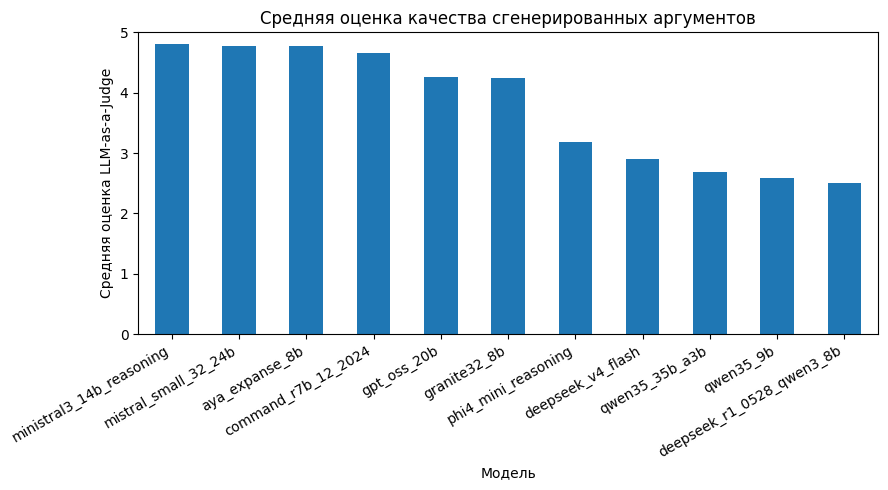

In [ ]:
plot_generation_model_summary(generation_model_summary)

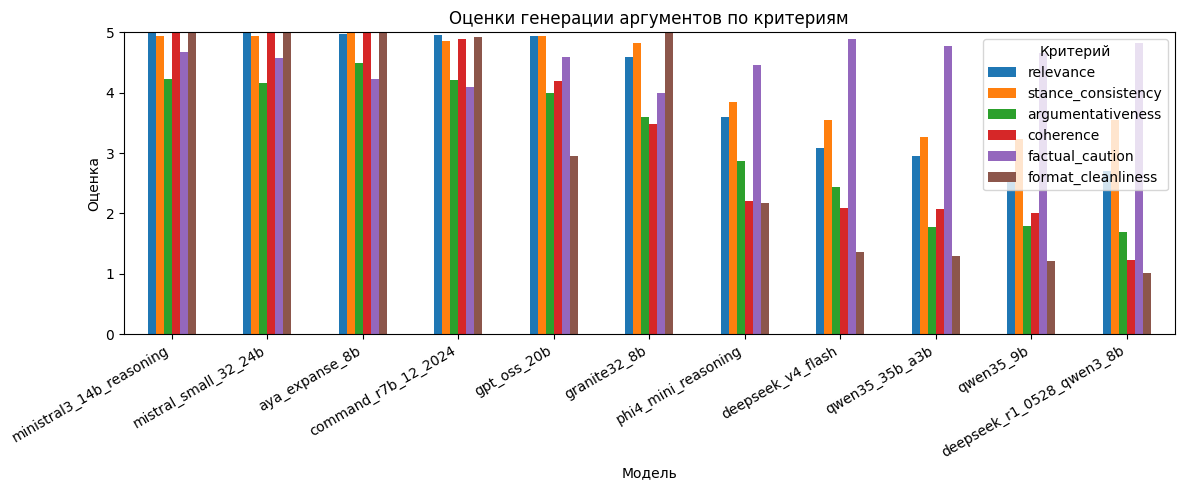

In [ ]:
plot_generation_criteria_summary(generation_model_summary)

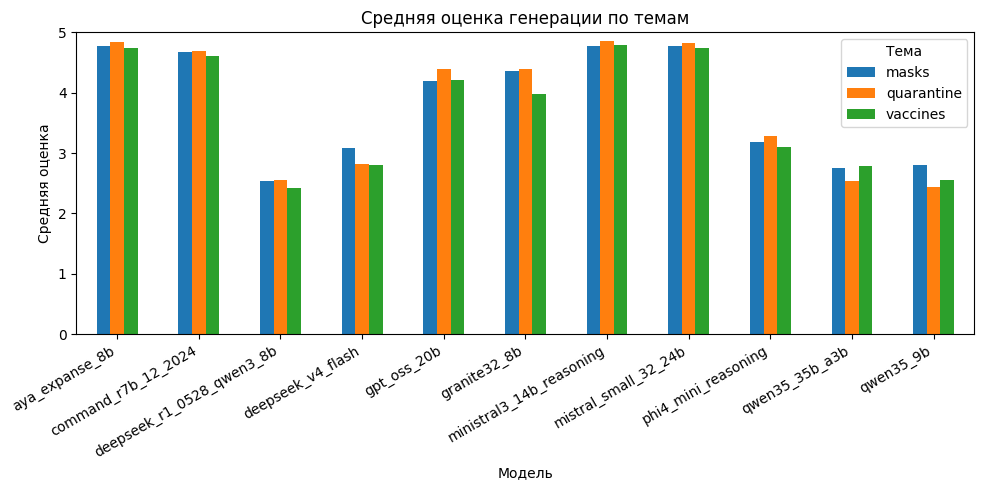

In [ ]:
plot_generation_topic_summary(generation_topic_summary)

**Примеры лучших и худших генераций**

In [ ]:
judged_df = pd.read_csv(JUDGE_DIR / "judged_arguments.csv")

for col in CRITERIA + ["mean_score"]:
    judged_df[col] = pd.to_numeric(judged_df[col], errors="coerce")

valid_judged_df = judged_df[judged_df["mean_score"].notna()].copy()

best_examples = valid_judged_df.sort_values("mean_score", ascending=False).head(10)
worst_examples = valid_judged_df.sort_values("mean_score", ascending=True).head(10)

In [ ]:
print("Лучшие примеры:")
display(
    best_examples[
        [
            "generated_by_model",
            "topic",
            "stance",
            "mean_score",
            "generated_argument",
            "comment",
        ]
    ]
)

Лучшие примеры:


,generated_by_model,topic,stance,mean_score,generated_argument,comment
773,gpt_oss_20b,quarantine,FOR,5.0,Карантин ограничивает массовые скопления людей...,Аргумент полностью соответствует всем критериям
446,command_r7b_12_2024,vaccines,FOR,5.0,Вакцинация protects individuals and communitie...,аргумент полностью соответствует всем критериям
174,ministral3_14b_reasoning,quarantine,FOR,5.0,Карантин позволяет предотвратить быструю распр...,аргумент полностью соответствует всем критериям
458,command_r7b_12_2024,vaccines,FOR,5.0,Вакцинация — это важный инструмент для защиты ...,Аргумент полностью соответствует всем критериям
164,ministral3_14b_reasoning,quarantine,FOR,5.0,"Карантин помогает society, reducing the spread...",аргумент полностью соответствует всем критериям
162,ministral3_14b_reasoning,quarantine,FOR,5.0,Карантин снижает нагрузку на медицинскую систе...,аргумент полностью соответствует всем критериям
854,mistral_small_32_24b,masks,FOR,5.0,Ношение масок снижает распространение инфекцио...,аргумент полностью соответствует всем критериям
847,mistral_small_32_24b,masks,FOR,5.0,"Ношение масок снижает риск передачи инфекции, ...",аргумент полностью соответствует всем критериям
132,ministral3_14b_reasoning,masks,FOR,5.0,Ношение масок снижает риск передачи респиратор...,аргумент полностью соответствует всем критериям
131,ministral3_14b_reasoning,masks,FOR,5.0,"Ношение масок в общественных местах, например,...",аргумент полностью соответствует всем критериям


In [ ]:
print("Худшие примеры:")
display(
    worst_examples[
        [
            "generated_by_model",
            "topic",
            "stance",
            "mean_score",
            "generated_argument",
            "comment",
        ]
    ]
)

Худшие примеры:


,generated_by_model,topic,stance,mean_score,generated_argument,comment
1264,qwen35_35b_a3b,quarantine,AGAINST,1.0,Thinking Process: 1. **Analyze the Request:** ...,аргумент отсутствует
1303,qwen35_35b_a3b,vaccines,AGAINST,1.0,Thinking Process: 1. **Analyze the Request:** ...,"аргумент отсутствует, представлен только проце..."
21,deepseek_v4_flash,masks,AGAINST,1.0,"`, etc. * Output only the argument itself. 2. ...",аргумент отсутствует
1275,qwen35_35b_a3b,quarantine,AGAINST,1.0,Thinking Process: 1. **Analyze the Request:** ...,"аргумент отсутствует, представлен только проце..."
1311,qwen35_35b_a3b,vaccines,AGAINST,1.0,Thinking Process: 1. **Analyze the Request:** ...,"аргумент отсутствует, представлен только проце..."
1006,qwen35_9b,quarantine,FOR,1.0,Thinking Process: 1. **Analyze the Request:** ...,"аргумент отсутствует, только технические поясн..."
1068,qwen35_9b,vaccines,AGAINST,1.0,Thinking Process: 1. **Analyze the Request:** ...,"аргумент отсутствует, есть только описание про..."
1069,qwen35_9b,vaccines,AGAINST,1.0,Thinking Process: 1. **Analyze the Request:** ...,"аргумент отсутствует, есть только повторяющийс..."
1307,qwen35_35b_a3b,vaccines,AGAINST,1.0,Thinking Process: 1. **Analyze the Request:** ...,аргумент отсутствует
1003,qwen35_9b,quarantine,FOR,1.0,Thinking Process: 1. **Analyze the Request:** ...,аргумент отсутствует


# **Сохранение результатов**

In [ ]:
def save_vkr_report_fragments(
    classification_summary: pd.DataFrame,
    classification_status: pd.DataFrame,
    generation_model_summary: pd.DataFrame,
    generation_topic_summary: pd.DataFrame,
    generation_stance_summary: pd.DataFrame,
    path: Path = RESULTS_DIR / "vkr_report_fragments.md",
) -> None:
    lines = []

    lines.append("# Фрагменты для ВКР\n")

    lines.append("## Эксперимент по классификации аргументов\n")
    lines.append(
        "В экспериментальной части была рассмотрена задача классификации аргументов "
        "на русскоязычном корпусе RuArg-2022. Для каждого текста задавался тезис, "
        "относительно которого модель должна была определить одну из трех меток: "
        "AGAINST — аргумент против тезиса, NO_ARG — отсутствие явного аргумента, "
        "FOR — аргумент в поддержку тезиса. Для повышения воспроизводимости все модели "
        "получали одинаковый prompt, одинаковые few-shot примеры и обрабатывали одну и ту же "
        "оценочную выборку.\n"
    )

    lines.append("### Статус запусков классификации\n")
    if classification_status is not None and not classification_status.empty:
        lines.append(classification_status.to_markdown(index=False))
    else:
        lines.append("Статус запусков классификации отсутствует.")
    lines.append("\n")

    lines.append("### Сводные результаты классификации\n")
    if classification_summary is not None and not classification_summary.empty:
        lines.append(classification_summary.to_markdown(index=False))
    else:
        lines.append("Сводная таблица классификации отсутствует.")
    lines.append("\n")

    lines.append("## Эксперимент по генерации аргументов\n")
    lines.append(
        "Во второй части эксперимента была рассмотрена задача генерации аргументов. "
        "Для каждой темы задавался тезис и требуемая позиция: FOR — аргумент в поддержку "
        "тезиса, AGAINST — аргумент против тезиса. Модель должна была сгенерировать один "
        "краткий аргумент на русском языке, содержащий обоснование, причину, следствие, "
        "пример или объяснение позиции.\n"
    )

    lines.append("## Методика оценки LLM-as-a-Judge\n")
    lines.append(
        "Для автоматической оценки качества сгенерированных аргументов использовался подход "
        "LLM-as-a-Judge. Модель-эксперт оценивала каждый аргумент по пяти критериям по шкале "
        "от 1 до 5: релевантность тезису, соответствие требуемой позиции, аргументативность, "
        "логическая связность и фактическая осторожность. Итоговая оценка рассчитывалась как "
        "среднее значение по указанным критериям.\n"
    )

    lines.append("### Сводные результаты генерации по моделям\n")
    if generation_model_summary is not None and not generation_model_summary.empty:
        lines.append(generation_model_summary.to_markdown(index=False))
    else:
        lines.append("Сводная таблица генерации отсутствует.")
    lines.append("\n")

    lines.append("### Результаты генерации по темам\n")
    if generation_topic_summary is not None and not generation_topic_summary.empty:
        lines.append(generation_topic_summary.to_markdown(index=False))
    else:
        lines.append("Таблица результатов по темам отсутствует.")
    lines.append("\n")

    lines.append("### Результаты генерации по позициям\n")
    if generation_stance_summary is not None and not generation_stance_summary.empty:
        lines.append(generation_stance_summary.to_markdown(index=False))
    else:
        lines.append("Таблица результатов по позициям отсутствует.")
    lines.append("\n")

    lines.append("## Ограничения эксперимента\n")
    lines.append(
        "Проведенное исследование имеет ряд ограничений. Во-первых, эксперименты проводились "
        "на ограниченной оценочной подвыборке, что связано с высокой вычислительной стоимостью "
        "локального запуска больших языковых моделей. Во-вторых, качество результатов зависит "
        "от формулировки prompt и способности модели соблюдать требуемый формат ответа. "
        "В-третьих, автоматическая оценка LLM-as-a-Judge не является полной заменой экспертной "
        "человеческой разметки, поэтому ее следует рассматривать как приближенный инструмент "
        "сравнительной оценки.\n"
    )
    lines.append(
    "При оценке классификационных экспериментов учитывались не только значения метрик, "
    "но и техническая валидность прогонов. Прогон считался невалидным, если модель часто "
    "возвращала некорректный формат ответа, что приводило к fallback, или если модель "
    "демонстрировала вырожденное поведение, предсказывая почти всегда один и тот же класс. "
    "Такие результаты не использовались как полноценная оценка качества модели.\n"
    )

    path.write_text("\n".join(lines), encoding="utf-8")


save_vkr_report_fragments(
    classification_summary=classification_summary_df,
    classification_status=classification_status_df,
    generation_model_summary=generation_model_summary,
    generation_topic_summary=generation_topic_summary,
    generation_stance_summary=generation_stance_summary,
)

print("Файл сохранен:", RESULTS_DIR / "vkr_report_fragments.md")

Файл сохранен: results_vkr_full_experiment\vkr_report_fragments.md


In [ ]:
archive_base = str(RESULTS_DIR)
archive_path = shutil.make_archive(archive_base, "zip", RESULTS_DIR)

print("Архив создан:", archive_path)

Архив создан: C:\Windows\System32\results_vkr_full_experiment.zip
